# Introduction


**File:** Notebook_Fast_k_IVP.ipynb 
\
**Author:** Elizabeth Gould
\
**Date:** 14.03.2026
\
**Problem:** Find $k_{\mu}\left(BR, dk, \mu, \psi_0^\prime\right)$

This is my Jupyter notebook for finding a model for the parameter dependence of the wavenumber of the fast oscillations of the solution to the IVP of the nonlinear Schrödinger equation for persistant current in a single micrometer scale gold loop ($M_{\mu}$). 

Our nonlinear time-independent Schrödinger equation is
\begin{equation}
H \psi = k^2 \psi = \left( i \frac{d}{dx} + \frac{\pi BR}{\Phi_0} \right)^2 \psi + \mu \frac{m_e}{\left|e\right|\hbar} \left|\psi\right|^2 \psi.
\end{equation}
Our observed approximate solution to the nonlinear Schrödinger equation is
\begin{equation}
\psi = e^{i M_{\mu} x} \left( a e^{i k_{\mu} x} + b e^{- i k_{\mu} x} \right),
\end{equation}
where $k_{\mu}$ and $M_{\mu}$ differ from the case of the linear Schrödinger equation, which has a solution of
\begin{equation}
\psi = e^{i M_0 x} \left( a e^{i k_0 x} + b e^{- i k_0 x} \right),
\end{equation}
with $M_{0}$ = $\frac{\pi BR}{\Phi_0}$, and $k_{0}$ = $k0 + \frac{dk}{2  R_{max} }$. This notebook calculates how $M_{\mu}$ depends on $B * R$, $dk$, $\mu$, and $\psi^\prime_0$. $k$ dependencies are not given, since we are assuming the loops are made of gold. $R$ dependence can be rescaled as a $B$ dependence for the IVP, as $B$ and $R$ only appear in our Schrödinger equation as $\frac{\pi BR}{\Phi_0}$. $A_0$ dependence can removed from our Schrödinger equation by appropriate rescaling of $\mu$ and $\psi_0^\prime$.

Calculations are performed on a grid, so that I can analyze the effects of changing one parameter with the other parameters kept fixed. Monte Carlo techniques are in principle valid, but our grid works well for our case.

# Building Grid

To start, I need to load all the libraries I will need. Then I need to either build my grid or load a grid I have previously built.

In [1]:
#--LIBRARIES--------

import eelib
from eelib import pi

import numpy as np
import pickle
import pandas as pd
from sklearn.linear_model import LinearRegression

#plotting
import matplotlib.pyplot as plt
import seaborn as sns #statistical data visualization

In [2]:
#--PARAMETERS--------

# note that k, B, and R are percents here, mu is not as its scale is unknown
dk = 0.5
R  = 1.0
B  = 0.5
mu = 1.0e-7

n_dk = 8
n_m  = 8
n_g  = 15
n_b  = 8

b_r  = (0.03, 1.0) # B here is B*R, since varying R will alter k, which I don't want
dk_r = (0.1, 0.9)
mu_r = (-8, -5)    #1.0e-8 to 1.0e-5

num_l = [n_m, n_dk, n_b, n_g]

In [3]:
#--CODE--

# This takes 11 - 12 hours on my little notebook computer

#make loop, grid, or system
gridl = eelib.grid_fast_osc(R, B, dk, mu)

gridl.makeGridPoints(mu=mu_r, dk=dk_r,B=b_r,num = num_l)
gridl.gridFastOsc()

Begin grid build:  0.0
Number of periods to calculate: 115200
mu: 0, dk: 0, Time: 0.0030333995819091797
mu: 0, dk: 1, Time: 1098.876627922058
mu: 0, dk: 2, Time: 2030.867130279541
mu: 0, dk: 3, Time: 2768.6265845298767
mu: 0, dk: 4, Time: 3627.0826580524445
mu: 0, dk: 5, Time: 4488.697884559631
mu: 0, dk: 6, Time: 5304.78898525238
mu: 0, dk: 7, Time: 6258.733418941498
mu: 1, dk: 0, Time: 7138.462620019913
mu: 1, dk: 1, Time: 7920.162797212601
mu: 1, dk: 2, Time: 8645.033728122711
mu: 1, dk: 3, Time: 9402.11033987999
mu: 1, dk: 4, Time: 10181.560862779617
mu: 1, dk: 5, Time: 10961.501674890518
mu: 1, dk: 6, Time: 11729.345112800598
mu: 1, dk: 7, Time: 12504.443764925003
mu: 2, dk: 0, Time: 13294.266727924347
mu: 2, dk: 1, Time: 14093.357146263123
mu: 2, dk: 2, Time: 14846.155398607254
mu: 2, dk: 3, Time: 15594.26377081871
mu: 2, dk: 4, Time: 16370.233153104782
mu: 2, dk: 5, Time: 17144.842828273773
mu: 2, dk: 6, Time: 17918.591629981995
mu: 2, dk: 7, Time: 18694.387511968613
mu: 3, dk: 

In [ ]:
filename = 'grid110'

# Since this takes a while to run and is used for a while, it is best to save a copy of the data.
file = open(filename, 'ab')
pickle.dump(gridl, file)
file.close()

In [3]:
filename = 'grid110'

# This is the loading script. Be careful of Python version.
file = open(filename, 'rb')    
gridl = pickle.load(file)
file.close()

The following statement is just to check that my grid object is correct.

In [4]:
gridl

Grid object to measure fast oscillations:
mu has 8 points from 1e-08 to 1e-05.
dk has 8 points from 0.1 to 0.9.
B has 8 points from 0.03 to 1.0.
R is: 1.0
A is: [1.]
k0 is: 12000000000.0
Grid size: 15
Total number of parameters: 115200

# Defining variables for analysis

The code here pulls all of the relevant data from our grid object. It is stored in two formats, one being numpy arrays, while the other is a Pandas dataframe. Pandas will be used for building my triangle plots with Seaborn, but I will run regression using the alternative storage system.

In [5]:
# Pull the grids of values from our object.

# independent variables
B_g = gridl.mfs     # B (for B * R)
dk_g = gridl.ewd    # k
mu_g = gridl.nls    # mu
dgrid = gridl.d0_grid

# dependent variables
fot = gridl.fast_osc_t[:,:,:,0,0,0,:,:]
fot0 = gridl.fast_osc_t_0[:,:,:,0,0,0,:,:]

The previous code gets the observed half period from the grid object. I instead want the change in my half period from the linear solution, as this is what I wish to model.

In [6]:
dfot = np.copy(fot)
dfot0 = np.copy(fot0)
for ii, kk in enumerate(dk_g):
    dfot[:,ii,:,:,:] = fot[:,ii,:,:,:] - pi /(eelib.kFAu+kk/1e-6/2.0)
    dfot0[:,ii,:,:,:] = fot0[:,ii,:,:,:] - pi /(eelib.kFAu+kk/1e-6/2.0)

I know that the derivative of $\psi$ is scaled based on the fast oscillation wavenumber. From previous regression runs, I know that the best scaling, which produces good, linear results, is done by the known full $k_0$ of the linear case. The $dk$ term of the linear case alters this value noticeably, while the change in wavenumber due to nonlinearity is irrelevant for this scaling.

In [7]:
dgridk = np.zeros((n_dk,n_g,n_g), dtype=complex)
for ii, kk in enumerate(dk_g):
    dgridk[ii] = dgrid/(eelib.kFAu+kk/1e-6/2.0)

In [ ]:
# This is the period of the fast oscillations of |psi|^2 without ee interaction.
# Note that the actual period of the fast oscillations is twice this period.

t_1 = pi/(eelib.kFAu)
t_new  = pi/(gridl.l_calc.k)

In [9]:
# Here we are changing the format of variable storage.
# This is intended for use with pandas.
# Columns are parameter / variable values here.

size = np.shape(fot.flatten())[0]
print(size)
npaf = np.zeros((size, 6))

sz = [n_dk*n_b*n_g**2, n_b*n_g**2, n_g **2, n_g, 1]

for imu in range(n_m):
    for ik in range(n_dk):
        for ib in range(n_b):
            for idr in range(n_g):
                for idi in range(n_g):
                    ind = imu*sz[0]+ik*sz[1]+ib*sz[2]+idr*sz[3]+idi
                    #npaf[ind, 0] = mfp[im]
                    #npaf[ind, 1] = ew[ik]
                    npaf[ind, 0] = mu_g[imu]
                    npaf[ind, 1] = dk_g[ik]
                    npaf[ind, 2] = B_g[ib]
                    npaf[ind, 3] = np.real(dgrid[idr, idi]) / (eelib.kFAu + dk_g[ik]/R /2.0)
                    npaf[ind, 4] = np.imag(dgrid[idr, idi]) / (eelib.kFAu + dk_g[ik]/R /2.0)
                    npaf[ind, 5] = fot[imu, ik, ib, idr, idi]-(pi / (eelib.kFAu + dk_g[ik]/R /2.0))

115200


In [19]:
# Now as a Pandas dataframe.
dfa = pd.DataFrame(npaf, columns = ["\u03BC", "dk", "B", "Re(ψ')", "Im(ψ')", "\u0394T_(fast)"])

# And to show it, to test our results.
dfa.head()

,μ,dk,B,Re(ψ'),Im(ψ'),ΔT_(fast)
0,1.000000e-08,0.1,0.03,-1.38081,-1.380810,7.108685e-17
1,1.000000e-08,0.1,0.03,-1.38081,-1.321546,-2.150544e-17
2,1.000000e-08,0.1,0.03,-1.38081,-1.204153,-1.255241e-16
3,1.000000e-08,0.1,0.03,-1.38081,-1.033794,-2.335232e-16
4,1.000000e-08,0.1,0.03,-1.38081,-0.817964,-3.429756e-16


Now for our triangle plots, to see with what we are working. Be patient as Seaborn tends to take a minute to produce graphs.

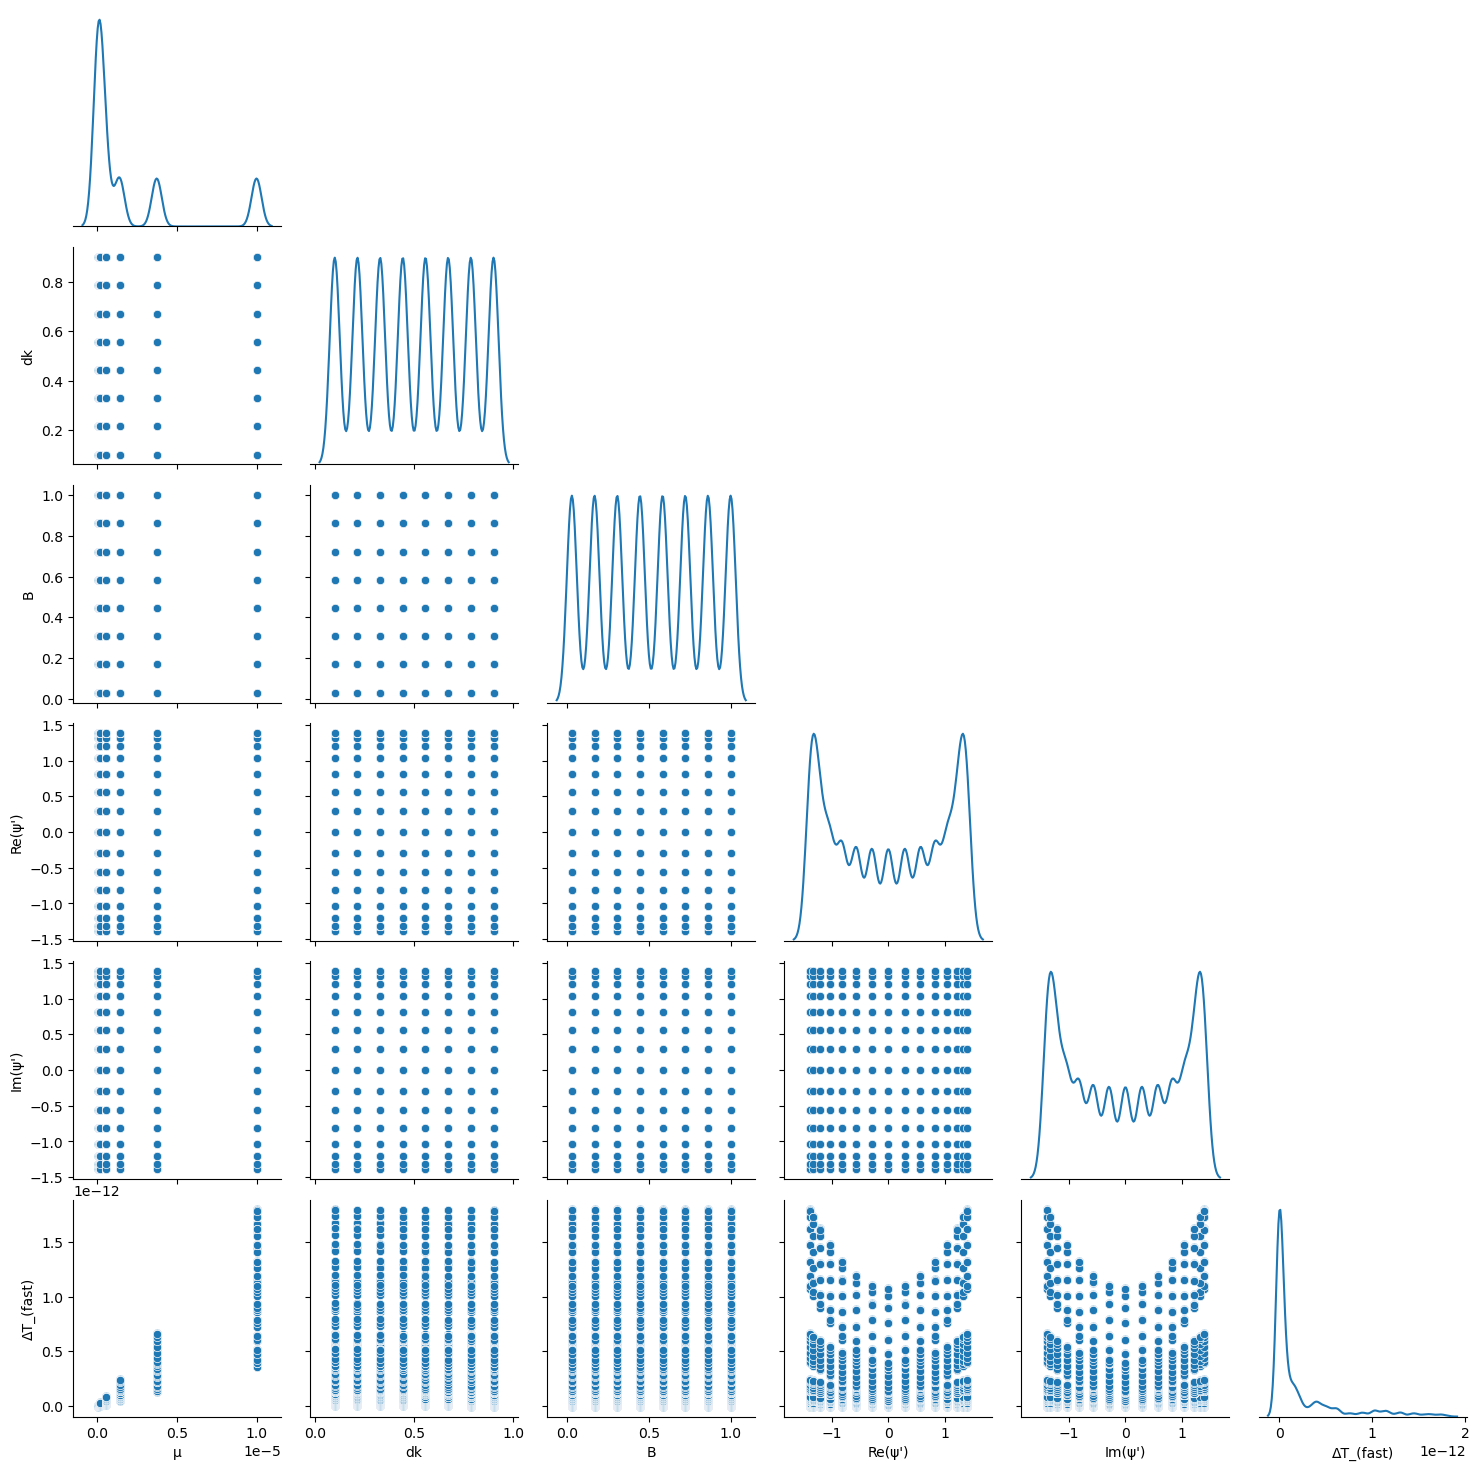

In [20]:
g = sns.PairGrid(dfa, diag_sharey=False, corner=True)

g.map_diag(sns.kdeplot)
g.map_lower(sns.scatterplot)

The expected pattern has appeared very clearly. The main, clearly visible term is $\mu\left|\frac{\psi^\prime}{k}\right|^2$.

# $\mu$ linear regression fitting

Linear regression will proceed as follows. I will fit $\mu^2$, $\mu$, and the intercept terms. $\mu$ should be primary, while $\mu^2$ and the intercept are the corrections. Corrections are important due to rapid oscillation.

I believe that the intercept term is due to a constant underestimating of the period, which exists even within the case without electron-electron interaction. This error is small, but adds up over oscillations, and therefore needs to be properly modelled in order to match the two sides. Fortunately, we have the exact solution without electron-electron interaction to aid in modelling. I also know that drop in amplitude for the electron-electron interaction case is identical to that without, so the issue should be solvable, and this error term can just be dropped when calculating the BVP matching.

Let us start with plotting. The plot here is done in the more standard MatPlotLib library.

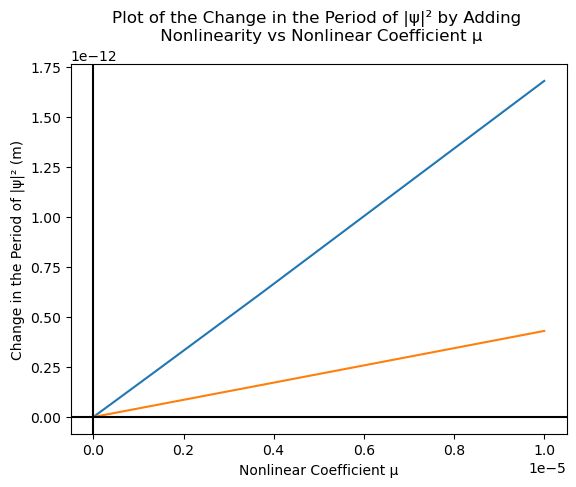

In [41]:
# The arrays here are designed to allow for easy modification of which plots to show.

ki  = [2, 6]
bi  = [3, 1]
d1i = [1, 8]
d2i = [1, 8]

ilim = min(len(ki), len(bi), len(d1i), len(d2i))

fig, ax = plt.subplots()
plt.title(f"Plot of the Change in the Period of |ψ|\u00b2 by Adding \n Nonlinearity vs Nonlinear Coefficient \u03BC")
ax.set_ylabel('Change in the Period of |ψ|\u00b2 (m)')
ax.set_xlabel("Nonlinear Coefficient \u03BC")

for i in range(ilim):
    ax.plot(mu_g, dfot[:, ki[i],bi[i],d1i[i],d2i[i]])
plt.axline((0,0), (1e-12,0), color='k')
plt.axline((0,0), (0,1e-12), color='k')
plt.show()

In [30]:
# 1% Error Tolerance

1/(1e-6/t_1) * pi/(eelib.kFAu + max(dk_g)/R /2.0) * 0.01

6.853891944943923e-16

We ideally want the error or imprecision of our model below $7 \times 10^{-16}$, which is required to prevent the error from adding up over the cycles. Note that dk doesn't change this estimate at all.

And now regression. We are fitting the following dependencies: $\mu^0$, $\mu$, and $\mu^2$. The $\mu$-intercept term is expected to be our error term from numerical analysis, which can be removed for BVP matching, while the other two terms likely have small enough error that they can be retained as found. We are fitting these $\mu$ dependencies seperately for all of our other parameters on our grid, as we will perform linear regression on the slope and intercept terms to determine dependence on other parameters. This technique is the reason for working on a grid of values, rather that attempting a Monte Carlo analysis.

In [31]:
slope = np.zeros((n_dk, n_b, n_g, n_g, 2))
intercept = np.zeros((n_dk, n_b, n_g, n_g))
r = 1.1    # for finding the minimum r value

for i in range(n_dk):
    for j in range(n_b):
        for k1 in range(n_g):
            for k2 in range(n_g):
                X = np.array([mu_g, np.power(mu_g,2)]).T
                y = dfot[:,i,j,k1,k2]

                reg = LinearRegression().fit(X, y)

                slope[i,j,k1,k2]=reg.coef_
                intercept[i,j,k1,k2]=reg.intercept_

                r2 = reg.score(X, y)
                r = min(r, r2)

                #print(i, j, k, slope[i,j,k], intercept[i,j,k])

print(r)

0.9999999811500869


Our calculated fit here is very good. From previous analysis, I know that for our required precision, our intercept term and $\mu^2$ term are required, but further terms are not.

In [32]:
np.min(dfot), np.max(dfot)

(-2.5061339710370244e-16, 1.8024813449445651e-12)

Now to show our ranges of regression parameters for all unregressed model parameters.

In [33]:
print(np.min(slope[:,:,:,:,0])*1e-6, np.max(slope[:,:,:,:,0])*1e-6)
print(np.min(slope[:,:,:,:,1])*1e-12, np.max(slope[:,:,:,:,1])*1e-12)
print(np.min(intercept), np.max(intercept))

3.674145048725801e-14 1.7695523194884252e-13
7.362217143096635e-18 3.3745010675670505e-16
-7.910990061590725e-16 -4.338195889677468e-16


# Visualization

This section is designed only to show various plots of our results from the regression of the previous section. It was used to understand which further regression is required.

In [34]:
slope_lin = slope[:,:,:,:,0]
slope_quad = slope[:,:,:,:,1]

The first graphs here show that dk dependence on our data is minimal, if any. Note that this says nothing of $k$ dependence, as $k$ is fixed to our Fermi wavenumber for gold. Large changes in $k$ have been shown to cause a power-law variation in our model, but the full $k$ analysis has not been performed.

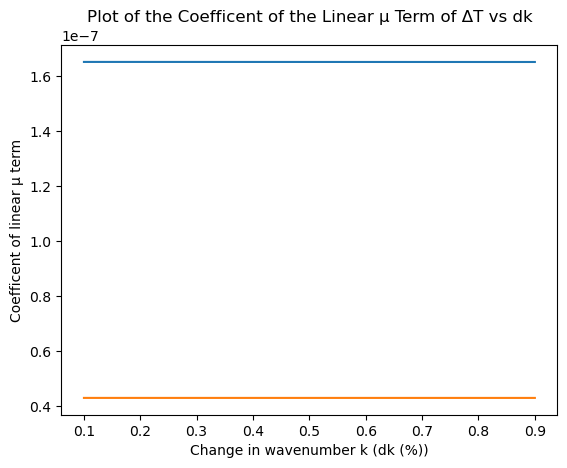

In [40]:
# dk vs linear mu dependence

ki  = [2, 6]
bi  = [3, 1]
d1i = [1, 8]
d2i = [1, 8]

ilim = max(len(ki), len(bi), len(d1i), len(d2i))

fig, ax = plt.subplots()

plt.title(f"Plot of the Coefficent of the Linear \u03BC Term of \u0394T vs dk")
ax.set_ylabel('Coefficent of linear \u03BC term')
ax.set_xlabel("Change in wavenumber k (dk (%))")

for i in range(ilim):
    ax.plot(dk_g, slope_lin[:,bi[i],d1i[i],d2i[i]])

plt.show()

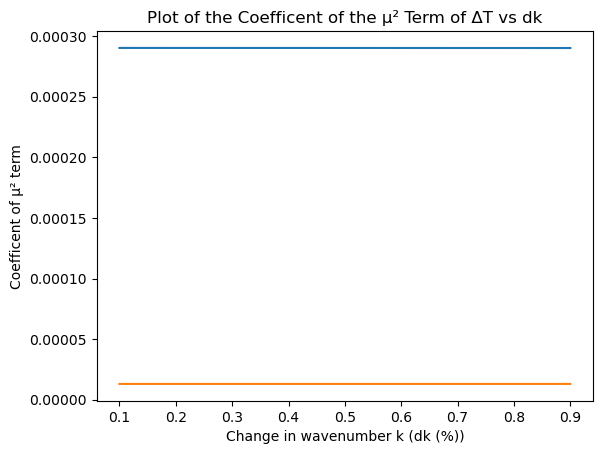

In [42]:
# dk vs quadratic mu dependence

ki  = [2, 6]
bi  = [3, 1]
d1i = [1, 8]
d2i = [1, 8]

ilim = max(len(ki), len(bi), len(d1i), len(d2i))

fig, ax = plt.subplots()
plt.title(f"Plot of the Coefficent of the \u03BC\u00b2 Term of \u0394T vs dk")
ax.set_ylabel('Coefficent of \u03BC\u00b2 term')
ax.set_xlabel("Change in wavenumber k (dk (%))")

for i in range(ilim):
    ax.plot(dk_g, slope_quad[:,bi[i],d1i[i],d2i[i]])

plt.show()

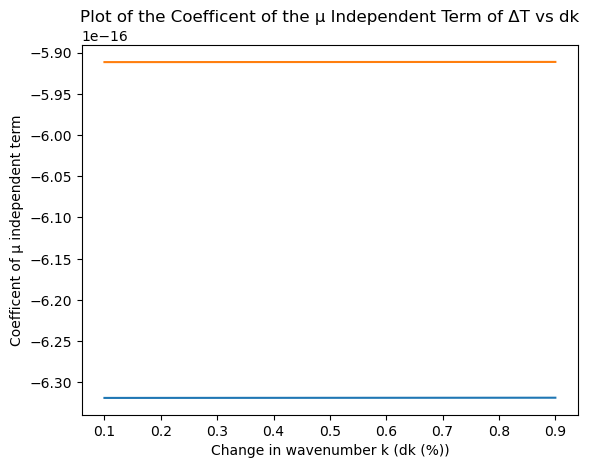

In [43]:
# dk vs terms independent of mu

ki  = [2, 6]
bi  = [3, 1]
d1i = [1, 8]
d2i = [1, 8]

ilim = max(len(ki), len(bi), len(d1i), len(d2i))

fig, ax = plt.subplots()
plt.title(f"Plot of the Coefficent of the \u03BC Independent Term of \u0394T vs dk")
ax.set_ylabel('Coefficent of \u03BC independent term')
ax.set_xlabel("Change in wavenumber k (dk (%))")

for i in range(ilim):
    ax.plot(dk_g, intercept[:,bi[i],d1i[i],d2i[i]])

plt.show()

The next plots here are for the $B$ dependence on our regression parameters. A minimal dependence is seen for one of the parameters, while the other parameters appear independent of $B$.

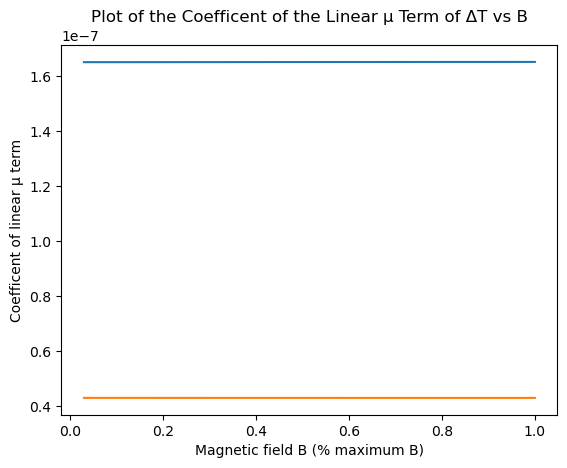

In [46]:
# B vs linear mu dependence

ki  = [2, 6]
bi  = [3, 1]
d1i = [1, 8]
d2i = [1, 8]

ilim = max(len(ki), len(bi), len(d1i), len(d2i))

fig, ax = plt.subplots()
plt.title(f"Plot of the Coefficent of the Linear \u03BC Term of \u0394T vs B")
ax.set_ylabel('Coefficent of linear \u03BC term')
ax.set_xlabel("Magnetic field B (% maximum B)")

for i in range(ilim):
    ax.plot(B_g, slope_lin[ki[i],:,d1i[i],d2i[i]])

plt.show()

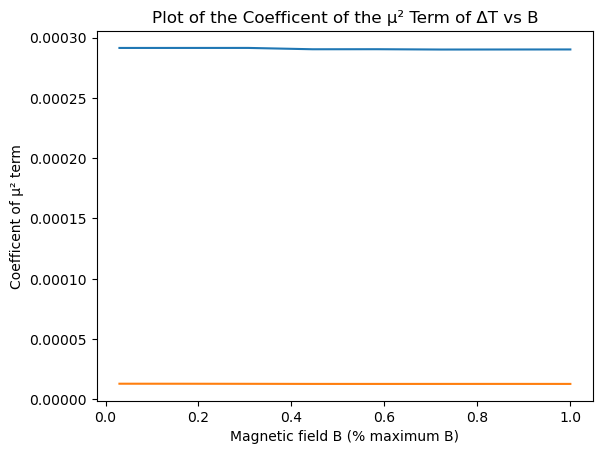

In [47]:
# B vs quadratic mu dependence

ki  = [2, 6]
bi  = [3, 1]
d1i = [1, 8]
d2i = [1, 8]

ilim = max(len(ki), len(bi), len(d1i), len(d2i))
fig, ax = plt.subplots()
plt.title(f"Plot of the Coefficent of the \u03BC\u00b2 Term of \u0394T vs B")
ax.set_ylabel('Coefficent of \u03BC\u00b2 term')
ax.set_xlabel("Magnetic field B (% maximum B)")

for i in range(ilim):
    ax.plot(B_g, slope_quad[ki[i],:,d1i[i],d2i[i]])

plt.show()

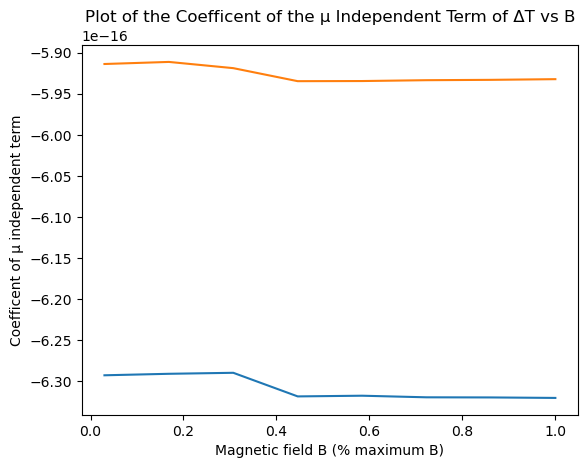

In [48]:
# B vs terms independent of mu

ki  = [2, 6]
bi  = [3, 1]
d1i = [1, 8]
d2i = [1, 8]

ilim = max(len(ki), len(bi), len(d1i), len(d2i))

fig, ax = plt.subplots()
plt.title(f"Plot of the Coefficent of the \u03BC Independent Term of \u0394T vs B")
ax.set_ylabel('Coefficent of \u03BC independent term')
ax.set_xlabel("Magnetic field B (% maximum B)")

for i in range(ilim):
    ax.plot(B_g, intercept[ki[i],:,d1i[i],d2i[i]])

plt.show()

Dependence of our regression parameters on $\frac{\psi^\prime_0}{k_{lin}}$ is seen below. We see linear, quadratic, and quartic terms, although the quartic terms are not so visible from these plots.

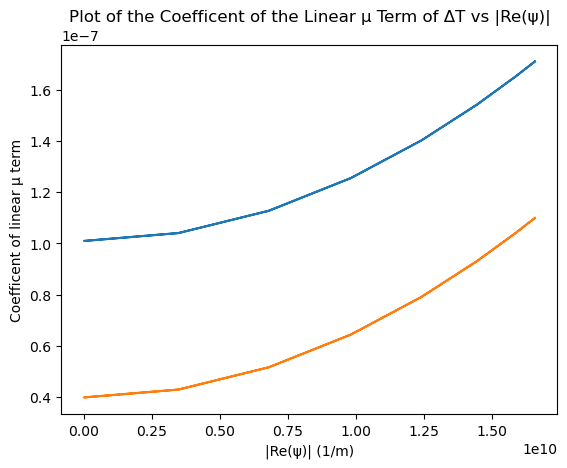

In [50]:
# The absolute value of the real part of the initial psi derivative vs linear mu dependence

ki  = [2, 6]
bi  = [3, 1]
d1i = [1, 8]
d2i = [1, 8]

ilim = max(len(ki), len(bi), len(d1i), len(d2i))

fig, ax = plt.subplots()
plt.title(f"Plot of the Coefficent of the Linear \u03BC Term of \u0394T vs |Re(ψ)|")
ax.set_ylabel('Coefficent of linear \u03BC term')
ax.set_xlabel("|Re(ψ)| (1/m)")

for i in range(ilim):
    ax.plot(np.abs(np.real(dgrid[:,d1i[i]])), slope_lin[ki[i],bi[i],d1i[i], :])

plt.show()

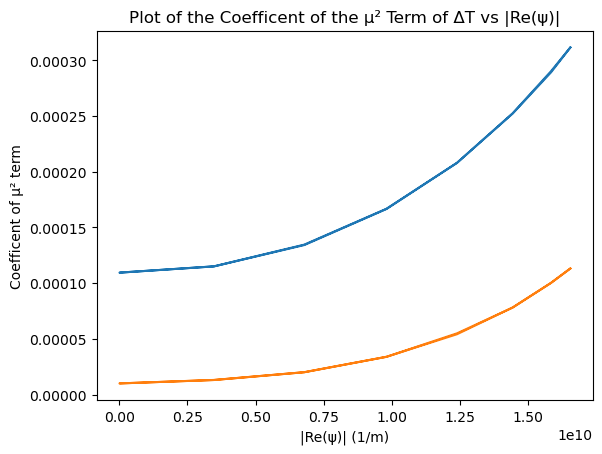

In [53]:
# The absolute value of the real part of the initial psi derivative vs quadratic mu dependence

ki  = [2, 6]
bi  = [3, 1]
d1i = [1, 8]
d2i = [1, 8]

ilim = max(len(ki), len(bi), len(d1i), len(d2i))

fig, ax = plt.subplots()
plt.title(f"Plot of the Coefficent of the \u03BC\u00b2 Term of \u0394T vs |Re(ψ)|")
ax.set_ylabel('Coefficent of \u03BC\u00b2 term')
ax.set_xlabel("|Re(ψ)| (1/m)")

for i in range(ilim):
    ax.plot(np.abs(np.real(dgrid[:,d1i[i]])), slope_quad[ki[i],bi[i],d1i[i], :])

plt.show()

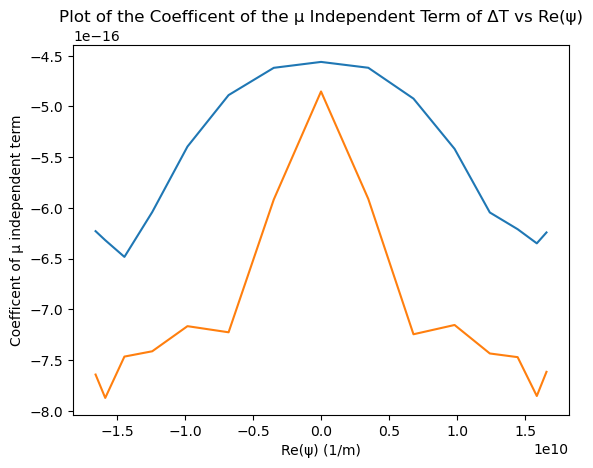

In [54]:
# The real part of the initial psi derivative vs terms independent of mu

ki  = [2, 6]
bi  = [3, 1]
d1i = [1, 8]
d2i = [1, 8]

ilim = max(len(ki), len(bi), len(d1i), len(d2i))

fig, ax = plt.subplots()
plt.title(f"Plot of the Coefficent of the \u03BC Independent Term of \u0394T vs Re(ψ)")
ax.set_ylabel('Coefficent of \u03BC independent term')
ax.set_xlabel("Re(ψ) (1/m)")

for i in range(ilim):
    ax.plot(np.real(dgrid[:,d1i[i]]), intercept[ki[i],bi[i],d1i[i], :])

plt.show()

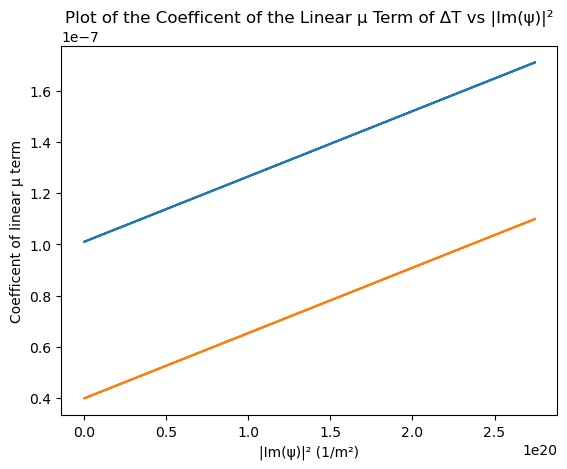

In [56]:
# The absolute value of the imaginary part of the initial psi derivative squared vs linear mu dependence

ki  = [2, 6]
bi  = [3, 1]
d1i = [1, 8]
d2i = [1, 8]

ilim = max(len(ki), len(bi), len(d1i), len(d2i))

fig, ax = plt.subplots()
plt.title(f"Plot of the Coefficent of the Linear \u03BC Term of \u0394T vs |Im(ψ)|\u00b2")
ax.set_ylabel('Coefficent of linear \u03BC term')
ax.set_xlabel("|Im(ψ)|\u00b2 (1/m\u00b2)")

for i in range(ilim):
    ax.plot(np.abs(np.imag(dgrid[d2i[i],:])**2), slope_lin[ki[i],bi[i],:,d2i[i]])

plt.show()

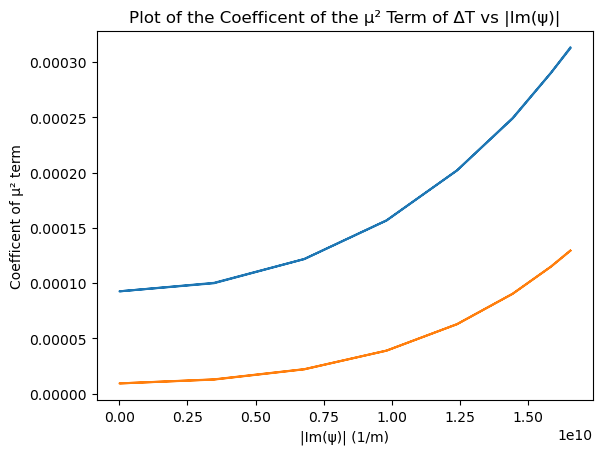

In [57]:
# The absolute value of the imaginary part of the initial psi derivative vs quadratic mu dependence

ki  = [2, 6]
bi  = [3, 1]
d1i = [1, 8]
d2i = [1, 8]

ilim = max(len(ki), len(bi), len(d1i), len(d2i))

fig, ax = plt.subplots()
plt.title(f"Plot of the Coefficent of the \u03BC\u00b2 Term of \u0394T vs |Im(ψ)|")
ax.set_ylabel('Coefficent of \u03BC\u00b2 term')
ax.set_xlabel("|Im(ψ)| (1/m)")

for i in range(ilim):
    ax.plot(np.abs(np.imag(dgrid[d2i[i],:])), slope_quad[ki[i],bi[i],:,d2i[i]])

plt.show()

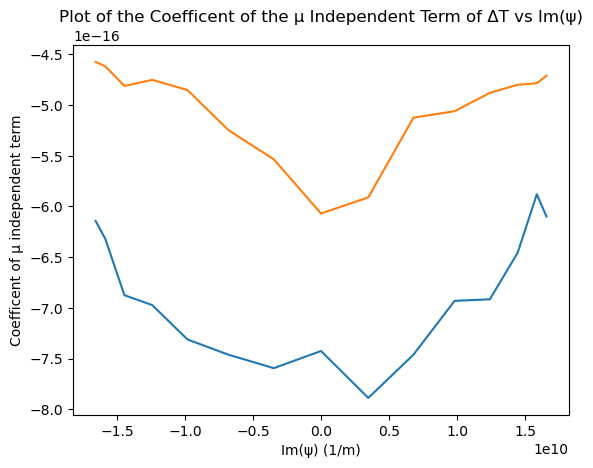

In [58]:
# The imaginary part of the initial psi derivative vs terms independent of mu

ki  = [2, 6]
bi  = [3, 1]
d1i = [1, 8]
d2i = [1, 8]

ilim = max(len(ki), len(bi), len(d1i), len(d2i))

fig, ax = plt.subplots()
plt.title(f"Plot of the Coefficent of the \u03BC Independent Term of \u0394T vs Im(ψ)")
ax.set_ylabel('Coefficent of \u03BC independent term')
ax.set_xlabel("Im(ψ) (1/m)")

for i in range(ilim):
    ax.plot(np.imag(dgrid[d2i[i],:]), intercept[ki[i],bi[i],:,d2i[i]])

plt.show()

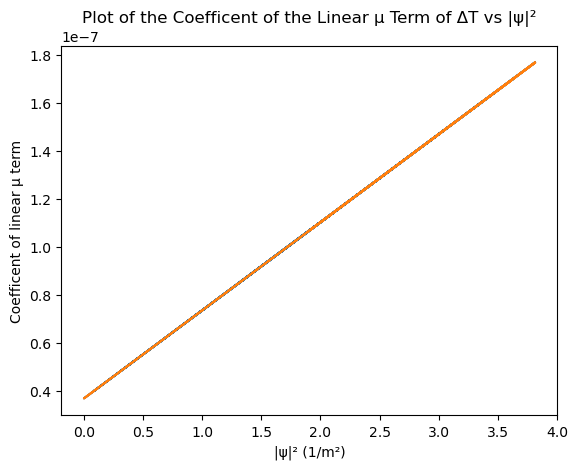

In [60]:
# The absolute value of the initial psi derivative squared vs linear mu dependence

ki  = [2, 6]
bi  = [7, 1]
d1i = [1, 8]
d2i = [1, 8]

ilim = max(len(ki), len(bi), len(d1i), len(d2i))

fig, ax = plt.subplots()
plt.title(f"Plot of the Coefficent of the Linear \u03BC Term of \u0394T vs |ψ|\u00b2")
ax.set_ylabel('Coefficent of linear \u03BC term')
ax.set_xlabel("|ψ|\u00b2 (1/m\u00b2)")

for i in range(ilim):
    ax.plot(np.abs(dgridk[ki[i]].flatten())**2, slope_lin[ki[i],bi[i]].flatten())

plt.show()

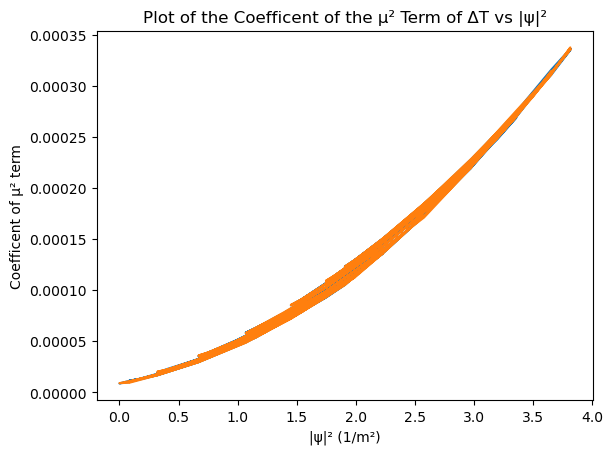

In [61]:
# The absolute value of the initial psi derivative squared vs quadratic mu dependence
# Here quartic terms are clearly visible, as is the divergence of the dependence on the real and imaginary parts of the initial psi derivative

ki  = [2, 6]
bi  = [7, 1]
d1i = [1, 8]
d2i = [1, 8]

ilim = max(len(ki), len(bi), len(d1i), len(d2i))

fig, ax = plt.subplots()
plt.title(f"Plot of the Coefficent of the \u03BC\u00b2 Term of \u0394T vs |ψ|\u00b2")
ax.set_ylabel('Coefficent of \u03BC\u00b2 term')
ax.set_xlabel("|ψ|\u00b2 (1/m\u00b2)")

for i in range(ilim):
    ax.plot(np.abs(dgridk[ki[i]].flatten())**2, slope_quad[ki[i],bi[i]].flatten())

plt.show()

# $\psi^\prime_0$ Regression

Our next dependence to find with linear regression will be all the dependencies on $\psi^\prime_0$, as they are the most obious in the previous graphs. These will be performed for each of the three regression parameters of the $\mu$ regression independently.

**$\mu$ term**

We will start by regressing our most prominant term of our $\mu$ regression. The following results are from regression for the following terms: $\mu \, \mathrm{Im} (\psi^\prime_0)$, $\mu \, |\mathrm{Im} (\psi^\prime_0)|^2$, $\mu \,|\mathrm{Re} (\psi^\prime_0)|^2$, and $\mu$ (the intercept term).

In [62]:
slope_md = np.zeros((n_dk,n_b,3))
intercept_md = np.zeros((n_dk,n_b))
r = 1.1    # for finding the minimum r value

# Real vs imag switch????

for ii in range(n_dk):
    for jj in range(n_b):
        X = np.array([np.imag(dgridk[ii].flatten()), np.imag(dgridk[ii].flatten())**2, np.real(dgridk[ii].flatten())**2]).T#, 
                      #np.real(dgridk[ii].flatten())**4, np.imag(dgridk[ii].flatten())**4, 
                      #np.real(dgridk[ii].flatten())**2*np.imag(dgridk[ii].flatten())**2]).T
        y = slope_lin[ii,jj].flatten()

        reg = LinearRegression().fit(X, y)

        slope_md[ii,jj]=reg.coef_
        intercept_md[ii,jj]=reg.intercept_

        r2 = reg.score(X, y)
        r = min(r, r2)

        #print(i, j, k, slope[i,j,k], intercept[i,j,k])

print(r)

0.9999999705357292


In [63]:
print(np.min(slope_md[:,:,0])*1e-6, np.max(slope_md[:,:,0])*1e-6)
print(np.min(slope_md[:,:,1])*1e-6, np.max(slope_md[:,:,1])*1e-6)
print(np.min(slope_md[:,:,2])*1e-6, np.max(slope_md[:,:,2])*1e-6)
print(np.min(intercept_md)*1e-6, np.max(intercept_md)*1e-6)

-6.014767526429437e-17 -1.6213042142443056e-18
3.6739861855126385e-14 3.67441508466703e-14
3.674136251695864e-14 3.674613560855049e-14
3.675199707757065e-14 3.6757569331473346e-14


The higher order terms may be relevant, but the main terms here are for $|\psi_0|^2$ and $|\psi^\prime_0|^2$ as expected, and they are all very close to each other. Lets look at the correction terms for other orders of $\mu$ now, and get back to this later.

**$\mu^2$ Terms**

The following results are from regression for the following terms: 
 - $\mu^2 \, |\mathrm{Im} (\psi^\prime_0)|^2$, 
 - $\mu^2 \, |\mathrm{Re} (\psi^\prime_0)|^2$, 
 - $\mu^2 \,|\mathrm{Re} (\psi^\prime_0)|^4$,
 - $\mu^2 \, |\mathrm{Im} (\psi^\prime_0)|^4$,
 - $\mu^2 \,|\mathrm{Re} (\psi^\prime_0)|^2|\mathrm{Im} (\psi^\prime_0)|^2$, and
 - $\mu^2$ (the intercept term).

In [64]:
slope_m2d = np.zeros((n_dk,n_b,5))
intercept_m2d = np.zeros((n_dk,n_b))
r = 1.1    # for finding the minimum r value


for ii in range(n_dk):
    for jj in range(n_b):
        X = np.array([np.imag(dgridk[ii].flatten())**2, np.real(dgridk[ii].flatten())**2, 
                      np.real(dgridk[ii].flatten())**4, np.imag(dgridk[ii].flatten())**4, 
                      np.real(dgridk[ii].flatten())**2*np.imag(dgridk[ii].flatten())**2]).T
        y = slope_quad[ii,jj].flatten()

        reg = LinearRegression().fit(X, y)

        slope_m2d[ii,jj]=reg.coef_
        intercept_m2d[ii,jj]=reg.intercept_

        r2 = reg.score(X, y)
        r = min(r, r2)

        #print(i, j, k, slope[i,j,k], intercept[i,j,k])

print(r)

0.9999579781625512


In [65]:
print(np.min(slope_m2d[:,:,0])*1e-12, np.max(slope_m2d[:,:,0])*1e-12)
print(np.min(slope_m2d[:,:,1])*1e-12, np.max(slope_m2d[:,:,1])*1e-12)
print(np.min(slope_m2d[:,:,2])*1e-12, np.max(slope_m2d[:,:,2])*1e-12)
print(np.min(slope_m2d[:,:,3])*1e-12, np.max(slope_m2d[:,:,3])*1e-12)
print(np.min(slope_m2d[:,:,4])*1e-12, np.max(slope_m2d[:,:,4])*1e-12)
print(np.min(intercept_m2d)*1e-12, np.max(intercept_m2d)*1e-12)

2.022305715136437e-17 2.0934951252454736e-17
2.8968952664544857e-17 2.976030488772717e-17
1.5801758037029615e-17 1.6147221536683318e-17
1.5753272740449312e-17 1.6082995212537806e-17
3.1680297787381756e-17 3.191290630821112e-17
8.304591428688054e-18 8.762777801040258e-18


Relevant for greater $\mu$. The term linear in $\mathrm{Im}(\psi^\prime_0)$ has been previously removed, as the statistics showed it to be irrelevant. 

**$\mu$ Intercept Terms**

The following results are from regression for the following terms: 
 - $|\mathrm{Im} (\psi^\prime_0)|^2$, 
 - $|\mathrm{Re} (\psi^\prime_0)|^2$,
 - $|\mathrm{Im} (\psi^\prime_0)|^4$,
 - and a term independent of all parameters so far (the intercept term).

In [66]:
slope_m0d = np.zeros((n_dk,n_b,3))
intercept_m0d = np.zeros((n_dk,n_b))
r = 1.1    # for finding the minimum r value


for ii in range(n_dk):
    for jj in range(n_b):
        X = np.array([np.imag(dgridk[ii].flatten())**2, np.real(dgridk[ii].flatten())**2, np.imag(dgridk[ii].flatten())**4]).T
        y = intercept[ii,jj].flatten()

        reg = LinearRegression().fit(X, y)

        slope_m0d[ii,jj]=reg.coef_
        intercept_m0d[ii,jj]=reg.intercept_

        r2 = reg.score(X, y)
        r = min(r, r2)

        #print(i, j, k, slope[i,j,k], intercept[i,j,k])

print(r)

0.8889668609438391


R here is low, but the error is expected to be chaotic, so this is normal.

In [67]:
print(np.min(slope_m0d[:,:,0]), np.max(slope_m0d[:,:,0]))
print(np.min(slope_m0d[:,:,1]), np.max(slope_m0d[:,:,1]))
print(np.min(slope_m0d[:,:,2]), np.max(slope_m0d[:,:,2]))
print(np.min(intercept_m0d), np.max(intercept_m0d))

-2.7900027660070167e-16 -2.731401617172611e-16
8.037421840671579e-17 8.159247478809074e-17
9.038943480850811e-17 9.360968170538544e-17
-5.709848101147942e-16 -5.683666387493814e-16


All these terms now need to be processed for $k$ and $B$ dependence. I am hoping all $k$ dependence has been removed within tolerance. I know $B$ has not, but it is not a strong signal.

# $k$ and $M$ Regression for $\mu$ Linear Term

Here we just want to show how many regressions we need to perform. There are so far 4 linear $\mu$ terms, three slopes with $\psi$ derivative dependence, and one intercept without $\psi$ derivative dependence.

In [68]:
np.shape(slope_md)

(8, 8, 3)

Now for our dk regression.

In [69]:
slope_mk = np.zeros((4,n_b,4))
intercept_mk = np.zeros((4,n_b))
r = 1.1    # for finding the minimum r value


for ii in range(3):
    for jj in range(n_b):
        X = np.array([dk_g, dk_g**2, np.power(dk_g,2), np.exp(dk_g)]).T
        y = slope_md[:,jj,ii]

        reg = LinearRegression().fit(X, y)

        slope_mk[ii,jj]=reg.coef_
        intercept_mk[ii,jj]=reg.intercept_

        r2 = reg.score(X, y)
        r = min(r, r2)

        print(ii, jj, slope_mk[ii,jj], intercept_mk[ii,jj], r2)

ii = 3

for jj in range(n_b):
    X = np.array([dk_g, dk_g**2, np.power(dk_g,2), np.exp(dk_g)]).T
    y = intercept_md[:,jj]

    reg = LinearRegression().fit(X, y)

    slope_mk[ii,jj]=reg.coef_
    intercept_mk[ii,jj]=reg.intercept_

    r2 = reg.score(X, y)
    r = min(r, r2)

    print(ii, jj, slope_mk[ii,jj], intercept_mk[ii,jj], r2)


print(r)

0 0 [-1.30187186e-12 -1.53825205e-12 -1.53825205e-12  2.61856698e-12] -4.519592895366406e-12 0.9413685871401098
0 1 [-7.36766462e-12 -3.42627501e-12 -3.42627501e-12  8.40851832e-12] -1.8668136348038358e-11 0.7021738683993874
0 2 [-1.18334793e-12 -5.74544099e-13 -5.74544099e-13  1.39378157e-12] -1.977387511113101e-11 0.4260406189615008
0 3 [ 6.02400107e-13  2.37041375e-13  2.37041375e-13 -6.29468440e-13] -2.5923619537303944e-11 0.6148131507070232
0 4 [-9.78040987e-13 -5.28738156e-13 -5.28738156e-13  1.18486720e-12] -3.626945510897546e-11 0.9783564931569866
0 5 [-1.04032232e-13 -9.63401150e-14 -9.63401150e-14  1.84977693e-13] -4.397387391025845e-11 0.8546186885431619
0 6 [ 1.05281460e-12  5.12515382e-13  5.12515382e-13 -1.21094758e-12] -5.058375339066265e-11 0.8601877686363603
0 7 [-1.03118413e-12 -1.83332077e-13 -1.83332077e-13  8.14408609e-13] -6.086073490823919e-11 0.655390063429756
1 0 [ 1.09035295e-11  5.73085400e-12  5.73085400e-12 -1.57492729e-11] 3.676034962365755e-08 0.994333433

In [70]:
print(np.min(slope_mk[:,:,0])*1e-6, np.max(slope_mk[:,:,0])*1e-6)
print(np.min(slope_mk[:,:,1])*1e-6, np.max(slope_mk[:,:,1])*1e-6)
print(np.min(slope_mk[:,:,2])*1e-6, np.max(slope_mk[:,:,2])*1e-6)
print(np.min(slope_mk[:,:,3])*1e-6, np.max(slope_mk[:,:,3])*1e-6)
print(np.min(intercept_mk)*1e-6, np.max(intercept_mk)*1e-6)

-4.150923171486685e-17 1.090352949777274e-17
-1.6950026647791556e-17 6.281694582238789e-18
-1.695002664779159e-17 6.281694582238802e-18
-1.5749272900074763e-17 4.1882345491272385e-17
-6.086073490823919e-17 3.6769897097955065e-14


The fit is often not very good, and appears to be around my tolerance level. The dominant term is in the intercept. We can just assume independence of dk and continue to $B$ dependence.

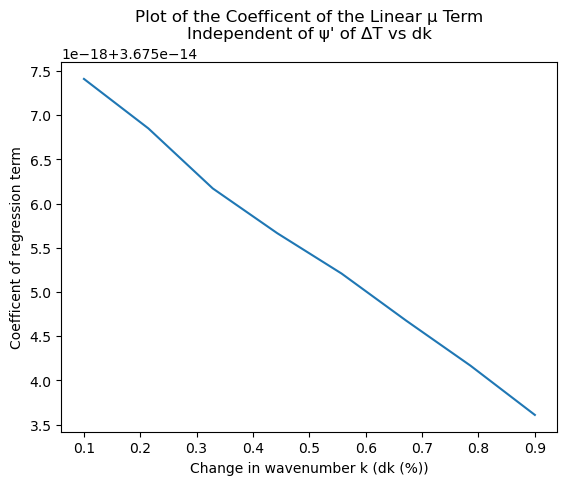

In [71]:
# Plot of dk vs linear mu term independent of psi derivative terms
# This shows a linear dependence, but small and within tolerance.

bi = [3]
dt = [5]

ilim = 1

fig, ax = plt.subplots()
plt.title(f"Plot of the Coefficent of the Linear \u03BC Term\nIndependent of ψ' of \u0394T vs dk")
ax.set_ylabel('Coefficent of regression term')
ax.set_xlabel("Change in wavenumber k (dk (%))")

for i in range(ilim):
    ax.plot(dk_g, intercept_md[:,bi[i]]*1e-6)

plt.show()

**B Dependence**

We are assuming that the data has $\frac{B}{k}$ dependence rather than separate B and k dependence. 

As far as I can tell, this term was not correct in the model I have been using, but I had effectively set it to zero, so it was just not used, and this didn't impact the results at all. When I ran this model before, I had found that this dependence still existed, since I had used the incorrect dependence in the model, and reran the regression, and readjusted the result. Later, when I used the model, I called the code with the true $B$ and $R$ instead of the percent $B$ and $R$ I used for regression, which significantly decreased this term, causing it to drop out of the results. I am going to keep what I have, since it works, but test my model with the corrected results.

In [28]:
M_g = B_g*1e-6*eelib.phi0inv

In [29]:
M_g[:]/(eelib.kFAu+dk_g[0]/1e-6/2)

array([0.00189908, 0.010671  , 0.01944293, 0.02821485, 0.03698677,
       0.0457587 , 0.05453062, 0.06330255])

In [30]:
M_g[:]/(eelib.kFAu+dk_g[7]/1e-6/2)

array([0.00189901, 0.01067065, 0.01944228, 0.02821391, 0.03698554,
       0.04575717, 0.0545288 , 0.06330044])

In [31]:
M_k = np.zeros((n_b,n_dk))
for ii in range(n_b):
    for jj in range(n_dk):
        M_k[ii,jj] = M_g[ii]/(eelib.kFAu+dk_g[jj]/1e-6/2)

M_k

array([[0.00189908, 0.00189907, 0.00189906, 0.00189905, 0.00189904,
        0.00189903, 0.00189902, 0.00189901],
       [0.010671  , 0.01067095, 0.0106709 , 0.01067085, 0.0106708 ,
        0.01067075, 0.0106707 , 0.01067065],
       [0.01944293, 0.01944283, 0.01944274, 0.01944265, 0.01944255,
        0.01944246, 0.01944237, 0.01944228],
       [0.02821485, 0.02821471, 0.02821458, 0.02821445, 0.02821431,
        0.02821418, 0.02821404, 0.02821391],
       [0.03698677, 0.0369866 , 0.03698642, 0.03698625, 0.03698607,
        0.03698589, 0.03698572, 0.03698554],
       [0.0457587 , 0.04575848, 0.04575826, 0.04575804, 0.04575783,
        0.04575761, 0.04575739, 0.04575717],
       [0.05453062, 0.05453036, 0.0545301 , 0.05452984, 0.05452958,
        0.05452932, 0.05452906, 0.0545288 ],
       [0.06330255, 0.06330225, 0.06330194, 0.06330164, 0.06330134,
        0.06330104, 0.06330074, 0.06330044]])

In [32]:
M_k**2

array([[3.60649116e-06, 3.60645681e-06, 3.60642247e-06, 3.60638812e-06,
        3.60635378e-06, 3.60631943e-06, 3.60628509e-06, 3.60625074e-06],
       [1.13870256e-04, 1.13869172e-04, 1.13868087e-04, 1.13867003e-04,
        1.13865918e-04, 1.13864834e-04, 1.13863750e-04, 1.13862665e-04],
       [3.78027333e-04, 3.78023733e-04, 3.78020133e-04, 3.78016533e-04,
        3.78012933e-04, 3.78009333e-04, 3.78005733e-04, 3.78002133e-04],
       [7.96077723e-04, 7.96070141e-04, 7.96062559e-04, 7.96054978e-04,
        7.96047397e-04, 7.96039816e-04, 7.96032235e-04, 7.96024654e-04],
       [1.36802142e-03, 1.36800840e-03, 1.36799537e-03, 1.36798234e-03,
        1.36796931e-03, 1.36795628e-03, 1.36794326e-03, 1.36793023e-03],
       [2.09385844e-03, 2.09383850e-03, 2.09381856e-03, 2.09379861e-03,
        2.09377867e-03, 2.09375873e-03, 2.09373879e-03, 2.09371885e-03],
       [2.97358876e-03, 2.97356044e-03, 2.97353213e-03, 2.97350381e-03,
        2.97347549e-03, 2.97344717e-03, 2.97341885e-03, 2.

In [33]:
slope_mM = np.zeros((4))
intercept_mM = np.zeros((4))
r = 1.1    # for finding the minimum r value


for ii in range(3):
    X = np.array([M_k.T.flatten()]).T
    y = slope_md[:,:,ii].flatten()

    reg = LinearRegression().fit(X, y)

    slope_mM[ii]=reg.coef_[0]
    intercept_mM[ii]=reg.intercept_

    r2 = reg.score(X, y)
    r = min(r, r2)

    print(ii, slope_mM[ii], intercept_mM[ii], r2)

ii = 3

X = np.array([M_k.T.flatten()]).T
y = intercept_md[:,:].flatten()

reg = LinearRegression().fit(X, y)

slope_mM[ii]=reg.coef_[0]
intercept_mM[ii]=reg.intercept_

r2 = reg.score(X, y)
r = min(r, r2)

print(ii, slope_mM[ii], intercept_mM[ii], r2)


print(r)

0 -9.523875302486646e-10 1.0797810302399725e-13 0.9999405002818106
1 -9.115586309896292e-12 3.674230161486211e-08 0.022727640885782163
2 1.1985522511484757e-11 3.6743259812298786e-08 0.036063591915547866
3 -1.1758373438242522e-11 3.6755324481870014e-08 0.030524784243274983
0.022727640885782163


M fitting doesn't help, except for the linear imaginary derivative term. These terms seem to help get the main signal closer to a uniform slope (if considered necessary), but for the quartic terms, there is no point. I will just ignore fitting the other terms in the model.

In [34]:
X = np.array([M_k.T.flatten()]).T
y = slope_md[:,:,0].flatten()

reg = LinearRegression(fit_intercept=False).fit(X, y)

slope_mMi=reg.coef_[0]
intercept_mMi=reg.intercept_

r2 = reg.score(X, y)

print(slope_mMi*1e-6*0.05, r2)

-4.749937809412049e-17 0.9999317369996303


In [35]:
intercept_mM = np.zeros((3))
r = 1.1    # for finding the minimum r value


for ii in range(1,3):
    intercept_mM[ii-1]=np.average(slope_md[:,:,ii])

    print(intercept_mM[ii-1]*1e-6)

ii = 2

intercept_mM[ii]=np.average(intercept_md[:,:])

print(intercept_mM[ii]*1e-6)

3.674200444430405e-14
3.674365054354659e-14
3.675494115574291e-14


Quartic terms appear unnecessary here. Lets go back to the $k$ dependence.

In [36]:
k_arr = np.zeros((n_dk, n_b))
for ii in range(n_dk):
    for jj in range(n_b):
        k_arr[ii,jj]=dk_g[ii]

In [37]:
k_arr = k_arr.flatten()

In [38]:
slope_mk = np.zeros((4,2))
intercept_mk = np.zeros((4))
r = 1.1    # for finding the minimum r value


for ii in range(3):
    X = np.array([k_arr, k_arr**2]).T
    y = slope_md[:,:,ii].flatten()

    reg = LinearRegression().fit(X, y)

    slope_mk[ii]=reg.coef_
    intercept_mk[ii]=reg.intercept_

    r2 = reg.score(X, y)
    r = min(r, r2)

    print(ii, slope_mk[ii]*1e-6, intercept_mk[ii]*1e-6, r2)

ii = 3

X = np.array([k_arr, k_arr**2]).T
y = intercept_md.flatten()

reg = LinearRegression().fit(X, y)

slope_mk[ii]=reg.coef_
intercept_mk[ii]=reg.intercept_

r2 = reg.score(X, y)
r = min(r, r2)

print(ii, slope_mk[ii]*1e-6, intercept_mk[ii]*1e-6, r2)


print(r)

0 [ 6.14176827e-20 -6.57390684e-20] -3.094987701890319e-17 4.57465423320258e-08
1 [-3.83686784e-18 -6.53954363e-19] 3.674413120940211e-14 0.9374030432525249
2 [-5.16664202e-18  4.96262484e-19] 3.6746075769508785e-14 0.9300881472909359
3 [-5.01963765e-18  3.58580208e-19] 3.675733674116089e-14 0.8144602631424371
4.57465423320258e-08


There is little evidence of any dependence. Everything is within error. Ok. Lets put together this mess.

In [39]:
consts = {}

In [40]:
consts["mA2"] = intercept_mM[2]
consts["mDIM"] = slope_mMi
consts["mDI2"] = intercept_mM[0]
consts["mDR2"] = intercept_mM[1]

In [41]:
consts

{'mA2': 3.6754941155742914e-08,
 'mDIM': -9.499875618824098e-10,
 'mDI2': 3.674200444430405e-08,
 'mDR2': 3.674365054354659e-08}

So far, first correction has 3 terms, and the second correction has one so far. The first correction is a reasonably simple model here, with one fitted parameter. The parameters only split around the point of my second correction. The second correction will be frustrating, however, and I don't know which terms are error. The $\mu$ intercept terms are definitely error. I will need to compare these to the numerical model without ee interaction.

# $k$ and $M$ Regression for $\mu^2$ Term

Here we just want to show how many regressions we need to perform. There are so far 6 quadratic $\mu$ terms, five slopes with $\psi$ derivative dependence, and one intercept without $\psi$ derivative dependence.

In [42]:
np.shape(slope_m2d)

(8, 8, 5)

We will proceed like before.

**k dependency terms**

In [43]:
slope_m2k = np.zeros((6,n_b,2))
intercept_m2k = np.zeros((6,n_b))
r = 1.1    # for finding the minimum r value


for ii in range(5):
    for jj in range(n_b):
        X = np.array([np.power(dk_g,1), np.power(dk_g,2)]).T
        y = slope_m2d[:,jj,ii]

        reg = LinearRegression().fit(X, y)

        slope_m2k[ii,jj]=reg.coef_
        intercept_m2k[ii,jj]=reg.intercept_

        r2 = reg.score(X, y)
        r = min(r, r2)

        print(ii, jj, slope_m2k[ii,jj]*1e-10, intercept_m2k[ii,jj]*1e-10, r2)

ii = 5

for jj in range(n_b):
    X = np.array([np.power(dk_g,1), np.power(dk_g,2)]).T
    y = intercept_m2d[:,jj]

    reg = LinearRegression().fit(X, y)

    slope_m2k[ii,jj]=reg.coef_
    intercept_m2k[ii,jj]=reg.intercept_

    r2 = reg.score(X, y)
    r = min(r, r2)

    print(ii, jj, slope_m2k[ii,jj]*1e-10, intercept_m2k[ii,jj]*1e-10, r2)


print(r)

0 0 [-4.97996421e-17  2.24301983e-17] 2.0955154027310114e-15 0.6536039094575258
0 1 [ 2.80469691e-18 -5.40151144e-18] 2.0516057397370527e-15 0.09386486641092706
0 2 [-1.31803468e-17  1.06114966e-17] 2.0727825731858468e-15 0.19410759156120005
0 3 [-2.5889114e-17  2.0313896e-17] 2.0807873064796803e-15 0.3398702825537022
0 4 [ 5.49412023e-19 -1.11231873e-17] 2.029846059284663e-15 0.8157369846935472
0 5 [-4.15140990e-18  6.30358811e-18] 2.0411433506012478e-15 0.7118758475746979
0 6 [ 3.10548639e-18 -6.20268053e-18] 2.0543859261560384e-15 0.6587598297876355
0 7 [-4.92170697e-17  4.06165489e-17] 2.062009754041154e-15 0.8222713619658507
1 0 [ 5.59836380e-17 -4.54991101e-17] 2.9550528862656607e-15 0.7994915397374673
1 1 [ 1.59342222e-17 -9.01200540e-18] 2.9386904000764276e-15 0.6458169379903214
1 2 [ 7.37230593e-18 -1.51799949e-17] 2.9743105941802717e-15 0.7564172088375065
1 3 [5.73032753e-18 1.51735676e-18] 2.9407290134716097e-15 0.8426005702211115
1 4 [-1.39309211e-17  1.34228758e-17] 2.9082

Nothing at our order, poor convergence, ... In theory I could claim something existed, but it seems unnecessary.

In [44]:
slope_m2M = np.zeros((6,2))
intercept_m2M = np.zeros((6))
r = 1.1    # for finding the minimum r value


for ii in range(5):
    X = np.array([M_k.T.flatten(), M_k.T.flatten()**2]).T
    y = slope_m2d[:,:,ii].flatten()

    reg = LinearRegression().fit(X, y)

    slope_m2M[ii]=reg.coef_[0]
    intercept_m2M[ii]=reg.intercept_

    r2 = reg.score(X, y)
    r = min(r, r2)

    print(ii, slope_m2M[ii]*1e-10*0.06, intercept_m2M[ii]*1e-10, r2)

ii = 5

X = np.array([M_k.T.flatten()]).T
y = intercept_m2d[:,:].flatten()

reg = LinearRegression().fit(X, y)

slope_m2M[ii]=reg.coef_[0]
intercept_m2M[ii]=reg.intercept_

r2 = reg.score(X, y)
r = min(r, r2)

print(ii, slope_m2M[ii]*1e-10*0.06, intercept_m2M[ii]*1e-10, r2)


print(r)

0 [-7.54936033e-17 -7.54936033e-17] 2.0778445343410927e-15 0.32731945012422603
1 [-5.57809655e-17 -5.57809655e-17] 2.968487913445462e-15 0.6727795684037601
2 [3.86383798e-17 3.86383798e-17] 1.5829064017782423e-15 0.5647254392767538
3 [5.26301449e-17 5.26301449e-17] 1.578546863931628e-15 0.4597033195435285
4 [-9.27278173e-18 -9.27278173e-18] 3.1808532960777838e-15 0.2616124065862714
5 [3.2511521e-17 3.2511521e-17] 8.34557619975712e-16 0.5596244300451512
0.2616124065862714


Nothing. 

In [45]:
ave_c_m2d = np.zeros((6))
for i in range(5):
    ave_c_m2d[i] = np.average(slope_m2d[:,:,i])
ave_c_m2d[5] = np.average(intercept_m2d)
print(ave_c_m2d*1e-10)

[2.05561148e-15 2.93585975e-15 1.59820712e-15 1.59105779e-15
 3.18235870e-15 8.52222358e-16]


These are only relevant for the largest $\mu$ values, which are likely unimportant. I will save them anyway.

In [46]:
consts["m2"] = ave_c_m2d[5]
consts["m2DI2"] = ave_c_m2d[0]
consts["m2DR2"] = ave_c_m2d[1]
consts["m2DR4"] = ave_c_m2d[2]
consts["m2DI4"] = ave_c_m2d[3]
consts["m2DI2R2"] = ave_c_m2d[4]

In [47]:
consts

{'mA2': 3.6754941155742914e-08,
 'mDIM': -9.499875618824098e-10,
 'mDI2': 3.674200444430405e-08,
 'mDR2': 3.674365054354659e-08,
 'm2': 8.522223583430335e-06,
 'm2DI2': 2.0556114758548026e-05,
 'm2DR2': 2.935859754513446e-05,
 'm2DR4': 1.5982071176096677e-05,
 'm2DI4': 1.5910577914323515e-05,
 'm2DI2R2': 3.182358695140477e-05}

# $k$ and $M$ Regression for $\mu$ Intercept Term

And for the final set, the error term independent of $\mu$.

In [48]:
slope_m0k = np.zeros((4,n_b,2))
intercept_m0k = np.zeros((4,n_b))
r = 1.1    # for finding the minimum r value


for ii in range(3):
    for jj in range(n_b):
        X = np.array([np.sin(pi*dk_g), np.cos(pi*dk_g)]).T
        y = slope_m0d[:,jj,ii]

        reg = LinearRegression().fit(X, y)

        slope_m0k[ii,jj]=reg.coef_
        intercept_m0k[ii,jj]=reg.intercept_

        r2 = reg.score(X, y)
        r = min(r, r2)

        print(ii, jj, slope_m0k[ii,jj], intercept_m0k[ii,jj], r2)

ii = 3

for jj in range(n_b):
    X = np.array([np.sin(pi*dk_g), np.cos(pi*dk_g)]).T
    y = intercept_m0d[:,jj]

    reg = LinearRegression().fit(X, y)

    slope_m0k[ii,jj]=reg.coef_
    intercept_m0k[ii,jj]=reg.intercept_

    r2 = reg.score(X, y)
    r = min(r, r2)

    print(ii, jj, slope_m0k[ii,jj], intercept_m0k[ii,jj], r2)


print(r)

0 0 [-1.75157013e-18  5.90869215e-19] -2.757122527641113e-16 0.6810883966909873
0 1 [-1.14451282e-18 -3.09946952e-20] -2.747566508603135e-16 0.35695032031642904
0 2 [-1.39000980e-18 -6.13896064e-19] -2.7371291499984453e-16 0.3828245942764755
0 3 [-2.00127428e-18 -2.41661820e-19] -2.752257823765628e-16 0.7540739651986158
0 4 [5.55825229e-19 4.13226292e-19] -2.788848045714939e-16 0.7487652850334419
0 5 [-4.45663652e-19  1.17545496e-19] -2.7647286538280822e-16 0.16292070036170359
0 6 [1.30439534e-18 2.84534795e-19] -2.765885279487949e-16 0.8352064590921746
0 7 [-4.30345399e-19 -3.69897931e-19] -2.7442820098109894e-16 0.8719342017976686
1 0 [ 2.44634972e-19 -4.58040316e-20] 8.041514825047806e-17 0.42563347265442764
1 1 [7.58183440e-20 9.59226065e-20] 8.067433829173892e-17 0.8063615442418456
1 2 [3.28147942e-19 5.77134205e-20] 8.10482994746872e-17 0.44208698650317113
1 3 [4.70257470e-19 5.70176003e-20] 8.070204815706334e-17 0.8721887717442445
1 4 [-1.07219077e-19 -1.01864257e-19] 8.15560332

Nothing.

In [49]:
slope_m0M = np.zeros((4,2))
intercept_m0M = np.zeros((4))
r = 1.1    # for finding the minimum r value


for ii in range(3):
    X = np.array([M_k.T.flatten(), M_k.T.flatten()**2]).T
    y = slope_m0d[:,:,ii].flatten()

    reg = LinearRegression().fit(X, y)

    slope_m0M[ii]=reg.coef_[0]
    intercept_m0M[ii]=reg.intercept_

    r2 = reg.score(X, y)
    r = min(r, r2)

    print(ii, slope_m0M[ii]*0.06, intercept_m2M[ii], r2)

ii = 3

X = np.array([M_k.T.flatten()]).T
y = intercept_m0d[:,:].flatten()

reg = LinearRegression().fit(X, y)

slope_m0M[ii]=reg.coef_[0]
intercept_m0M[ii]=reg.intercept_

r2 = reg.score(X, y)
r = min(r, r2)

print(ii, slope_m0M[ii]*0.06, intercept_m0M[ii], r2)


print(r)

0 [-4.65201631e-18 -4.65201631e-18] 2.0778445343410925e-05 0.1434507658007379
1 [3.18608464e-18 3.18608464e-18] 2.968487913445462e-05 0.7400688929470145
2 [5.5400165e-18 5.5400165e-18] 1.5829064017782422e-05 0.3811535600657432
3 [-6.20169984e-20 -6.20169984e-20] -5.697027686587539e-16 0.0016142952925090048
0.0016142952925090048


Nothing again.

In [50]:
consts["intercept"] = np.average(intercept_m0d)
consts["DI2"] = np.average(slope_m0d[:,:,0])
consts["DR2"] = np.average(slope_m0d[:,:,1])
consts["DI4"] = np.average(slope_m0d[:,:,2])

In [51]:
consts

{'mA2': 3.6754941155742914e-08,
 'mDIM': -9.499875618824098e-10,
 'mDI2': 3.674200444430405e-08,
 'mDR2': 3.674365054354659e-08,
 'm2': 8.522223583430335e-06,
 'm2DI2': 2.0556114758548026e-05,
 'm2DR2': 2.935859754513446e-05,
 'm2DR4': 1.5982071176096677e-05,
 'm2DI4': 1.5910577914323515e-05,
 'm2DI2R2': 3.182358695140477e-05,
 'intercept': -5.697364648383742e-16,
 'DI2': -2.7618261397447087e-16,
 'DR2': 8.096011431463604e-17,
 'DI4': 9.192981818185883e-17}

Ok. Now to test the model. (And compare to the old model from the other grid.)

# $\mu B \, \mathrm{Im}(\psi^\prime_0)$ Term, Attempt 2

I want to try to recreate my results of my old model for the problematic term from first principles.

In [52]:
X = np.array(8*list(B_g))
X = X.reshape(-1,1)
y = slope_md[:,:,0].flatten()

reg = LinearRegression(fit_intercept=False).fit(X, y)

slope_mMi2=reg.coef_[0]
intercept_mMi2=reg.intercept_

r2 = reg.score(X, y)

print(slope_mMi*1e-6*0.05, r2)

-4.749937809412049e-17 0.9999317383007662


In [53]:
slope_mMi2

-6.013562964001457e-11

This is not the same number. It is somewhat close, however.

# Model Testing

Ok. Now that we have a model, we need to test it.

In [54]:
np.shape(dgridk)

(8, 15, 15)

In [91]:
consts = eelib.k_M_models_ivp.const_dic_001

This is a list of our saved values.

In [92]:
consts

{'mA2': 3.675494115574291e-08,
 'mDIM': -9.499875618824098e-10,
 'mDI2': 3.674200444430406e-08,
 'mDR2': 3.674365054354659e-08,
 'm2': 8.522223583430349e-06,
 'm2DI2': 2.0556114758548036e-05,
 'm2DR2': 2.9358597545134476e-05,
 'm2DR4': 1.598207117609667e-05,
 'm2DI4': 1.5910577914323505e-05,
 'm2DI2R2': 3.182358695140475e-05,
 'intercept': -5.697364648383741e-16,
 'DI2': -2.7618261397447087e-16,
 'DR2': 8.0960114314636e-17,
 'DI4': 9.19298181818588e-17}

In [74]:
# This is the value for 'mDIM' which we got from the above regression.
# It is unnecessary for our purposes, but is needed to reproduce the final results.
consts['mDIM'] = -9.499875618824098e-10
#consts['mDIM'] = -6.013562964001457e-11

In [75]:
dgrid_n = dgrid * t_new / eelib.pi

Lets start by testing the simplified version of our model with only the dominant terms.

In [76]:
t_pred = np.zeros((n_m, n_dk, n_b, n_g, n_g))

for mm in range(n_m): 
    for kk in range(n_dk):
        for nn in range (n_b):
            for ii in range(n_g):
                for jj in range(n_g):
                    # constant terms -- t_0 and intercept (error)
                    t_pred[mm,kk,nn,ii,jj] = pi /(eelib.kFAu+dk_g[kk]/1e-6/2.0) + consts['intercept']
                    # terms independent of mu (error)
                    #t_pred[mm,kk,nn,ii,jj] += (np.real(dgridk[kk,ii,jj])**2 * consts['DR2'] 
                    #                         + np.imag(dgridk[kk,ii,jj])**2 * consts['DI2'] 
                    #                         + np.imag(dgridk[kk,ii,jj])**4 * consts['DI4'])

                    # mu linear terms
                    t_pred[mm,kk,nn,ii,jj] += mu_g[mm]*(consts['mDR2'] * np.real(dgridk[kk,ii,jj])**2
                                                      + consts['mDI2'] * np.imag(dgridk[kk,ii,jj])**2
                                                      + consts['mA2'])
                                                      #+ consts['mDIM'] * np.imag(dgridk[kk,ii,jj]) * B_g[nn])

                    # mu quadradic terms
                    #t_pred[mm,kk,nn,ii,jj] += mu_g[nn]**2*(consts['m2']
                    #        + consts['m2DI2'] * np.imag(dgridk[kk,ii,jj])**2
                    #        + consts['m2DR2'] * np.real(dgridk[kk,ii,jj])**2 
                    #        + consts['m2DR4'] * np.real(dgridk[kk,ii,jj])**4 
                    #        + consts['m2DI4'] * np.imag(dgridk[kk,ii,jj])**4
                    #        + consts['m2DI2R2'] * np.real(dgridk[kk,ii,jj])**2 * np.imag(dgridk[kk,ii,jj])**2)
                    

In [77]:
# Maximum error
np.max(fot-t_pred), np.min(fot-t_pred)

(3.4409606539649355e-14, -2.2994415196096463e-16)

Not good enough.

In [95]:
# Here is our full model.

t_pred = np.zeros((n_m, n_dk, n_b, n_g, n_g))

for mm in range(n_m): 
    for kk in range(n_dk):
        for nn in range (n_b):
            for ii in range(n_g):
                for jj in range(n_g):
                    # constant terms -- t_0 and intercept (error)
                    t_pred[mm,kk,nn,ii,jj] = pi /(eelib.kFAu+dk_g[kk]/1e-6/2.0) + consts['intercept']
                    # terms independent of mu (error)
                    t_pred[mm,kk,nn,ii,jj] += (np.real(dgridk[kk,ii,jj])**2 * consts['DR2'] 
                                             + np.imag(dgridk[kk,ii,jj])**2 * consts['DI2'] 
                                             + np.imag(dgridk[kk,ii,jj])**4 * consts['DI4'])

                    # mu linear terms
                    t_pred[mm,kk,nn,ii,jj] += mu_g[mm]*(consts['mDR2'] * np.real(dgridk[kk,ii,jj])**2
                                                      + consts['mDI2'] * np.imag(dgridk[kk,ii,jj])**2
                                                      + consts['mA2']
                                                      + consts['mDIM'] * np.imag(dgridk[kk,ii,jj]) * B_g[nn])

                    # mu quadradic terms
                    t_pred[mm,kk,nn,ii,jj] += mu_g[mm]**2*(consts['m2']
                            + consts['m2DI2'] * np.imag(dgridk[kk,ii,jj])**2
                            + consts['m2DR2'] * np.real(dgridk[kk,ii,jj])**2 
                            + consts['m2DR4'] * np.real(dgridk[kk,ii,jj])**4 
                            + consts['m2DI4'] * np.imag(dgridk[kk,ii,jj])**4
                            + consts['m2DI2R2'] * np.real(dgridk[kk,ii,jj])**2 * np.imag(dgridk[kk,ii,jj])**2)

In [79]:
# Lets check our maximum error
np.max(fot-t_pred), np.min(fot-t_pred)

(1.2382867069769422e-14, -1.242798698055302e-14)

I seem to have gotten something better when I reran the regression.

In [64]:
mu_g

array([1.00000000e-08, 2.68269580e-08, 7.19685673e-08, 1.93069773e-07,
       5.17947468e-07, 1.38949549e-06, 3.72759372e-06, 1.00000000e-05])

Ok, now for our triangle plots.

In [96]:
size = np.shape(fot.flatten())[0]
print(size)
npaf = np.zeros((size, 6))

sz = [n_dk*n_b*n_g**2, n_b*n_g**2, n_g **2, n_g, 1]

for imu in range(n_m):
    for ik in range(n_dk):
        for ib in range(n_b):
            for idr in range(n_g):
                for idi in range(n_g):
                    ind = imu*sz[0]+ik*sz[1]+ib*sz[2]+idr*sz[3]+idi
                    #npaf[ind, 0] = mfp[im]
                    #npaf[ind, 1] = ew[ik]
                    npaf[ind, 0] = mu_g[imu]
                    npaf[ind, 1] = dk_g[ik]
                    npaf[ind, 2] = B_g[ib]
                    npaf[ind, 3] = np.real(dgrid[idr, idi]) / (eelib.kFAu + dk_g[ik]/R /2.0)
                    npaf[ind, 4] = np.imag(dgrid[idr, idi]) / (eelib.kFAu + dk_g[ik]/R /2.0)
                    npaf[ind, 5] = fot[imu, ik, ib, idr, idi]-t_pred[imu, ik, ib, idr, idi]

115200


In [97]:
dfa = pd.DataFrame(npaf, columns = ["\u03BC", "dk", "B", "Re(ψ')", "Im(ψ')", "\u0394T_(fast)"])

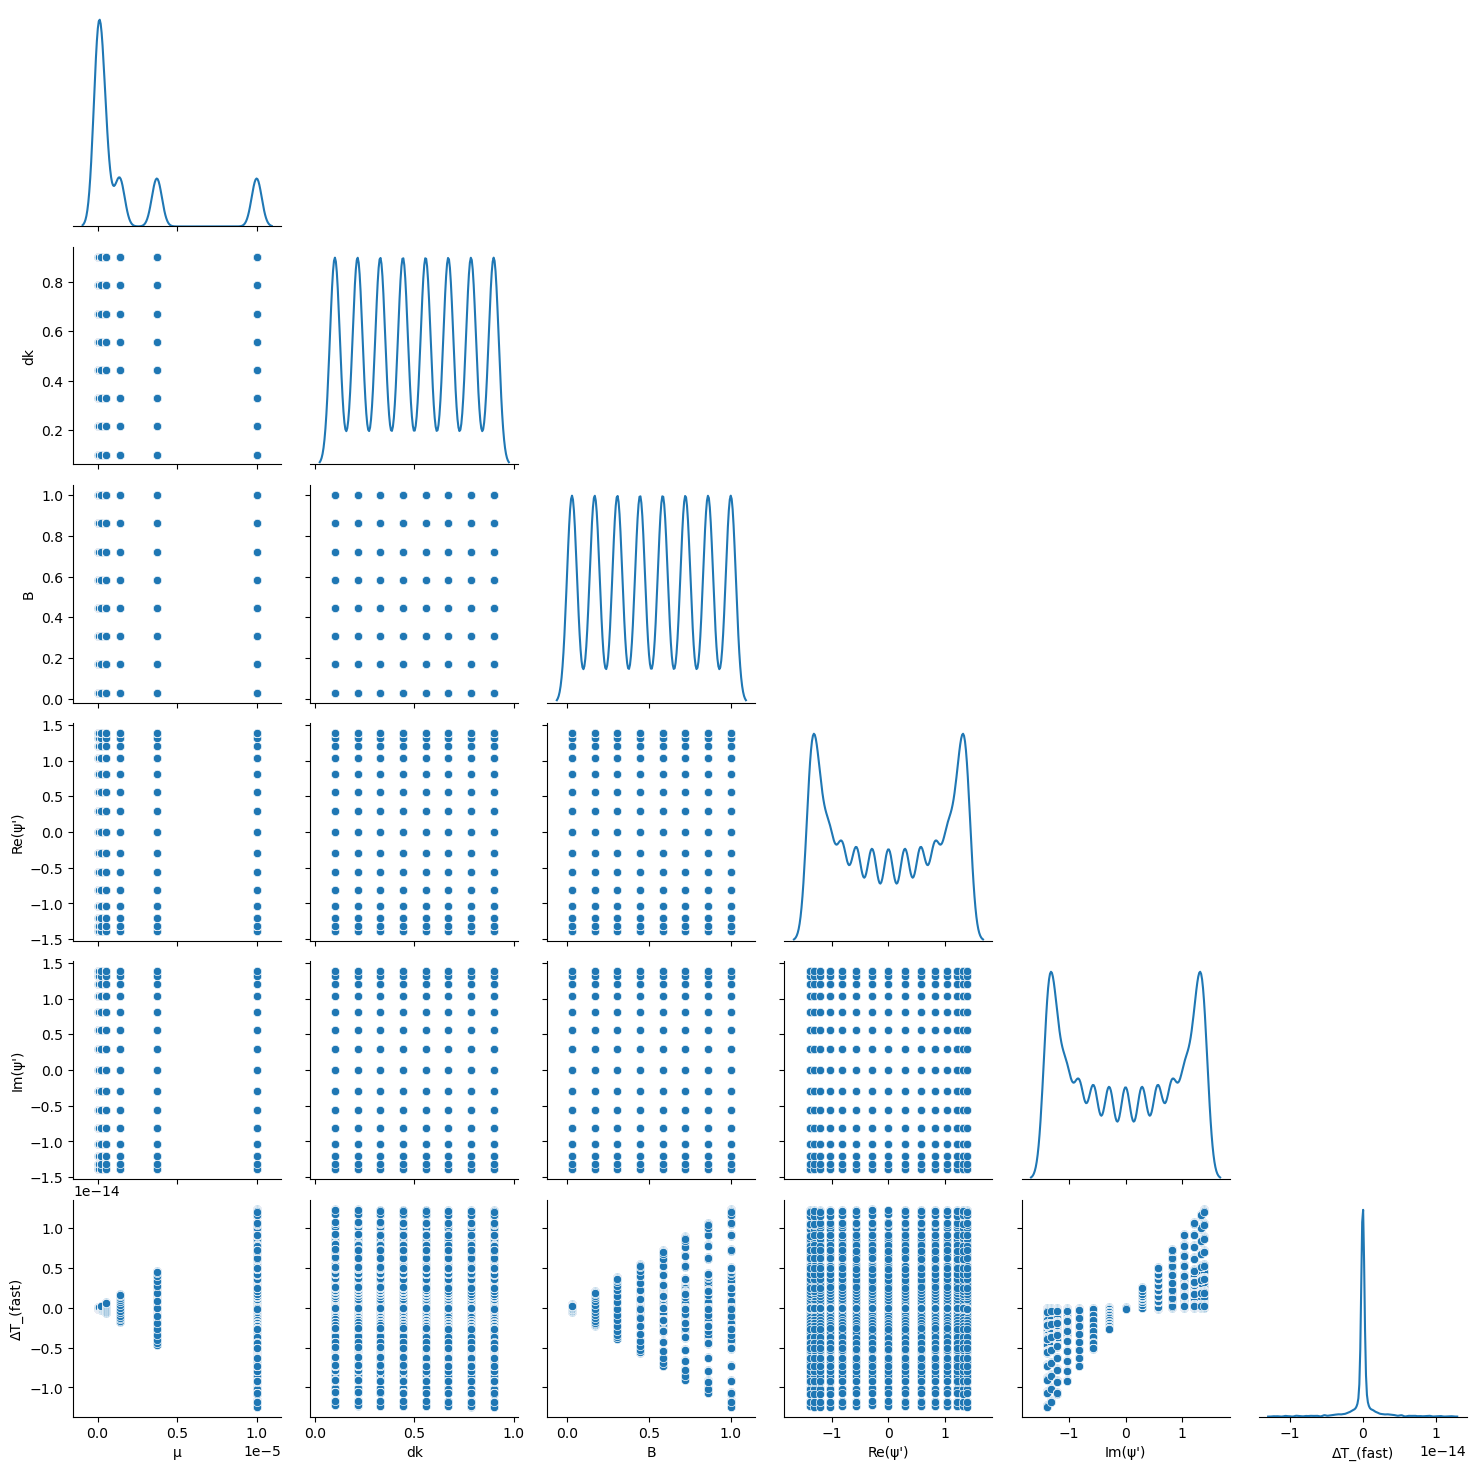

In [82]:
g = sns.PairGrid(dfa, diag_sharey=False, corner=True)

g.map_diag(sns.kdeplot)
g.map_lower(sns.scatterplot)

When the $\mu B \, \mathrm{Im}(\psi^\prime_0)$ term is incorrect, the signal is clearly visible. For better results, there are still signals here, but I hope that we are already within tolerance. Linear, quadratic, and quartic terms are visible. Taylor expansion approximations work great for our dataset. 

# Without ee interaction

Now for the triangle plots of the linear case. This code is designed to confirm that the erroneous terms independent of $\mu$ also exist for the linear case. When we constructed our grid, we had numerically analyzed the linear solution as well, in order to check this data.

In [83]:
size = np.shape(fot.flatten())[0]
print(size)
npaf = np.zeros((size, 6))

sz = [n_dk*n_b*n_g**2, n_b*n_g**2, n_g **2, n_g, 1]

for imu in range(n_m):
    for ik in range(n_dk):
        for ib in range(n_b):
            for idr in range(n_g):
                for idi in range(n_g):
                    ind = imu*sz[0]+ik*sz[1]+ib*sz[2]+idr*sz[3]+idi
                    #npaf[ind, 0] = mfp[im]
                    #npaf[ind, 1] = ew[ik]
                    npaf[ind, 0] = mu_g[imu]
                    npaf[ind, 1] = dk_g[ik]
                    npaf[ind, 2] = B_g[ib]
                    npaf[ind, 3] = np.real(dgrid[idr, idi]) / (eelib.kFAu + dk_g[ik]/R /2.0)
                    npaf[ind, 4] = np.imag(dgrid[idr, idi]) / (eelib.kFAu + dk_g[ik]/R /2.0)
                    npaf[ind, 5] = dfot0[imu, ik, ib, idr, idi]

115200


In [84]:
dfa = pd.DataFrame(npaf, columns = ["\u03BC", "dk", "B", "Re(ψ')", "Im(ψ')", "\u0394T_(fast)"])

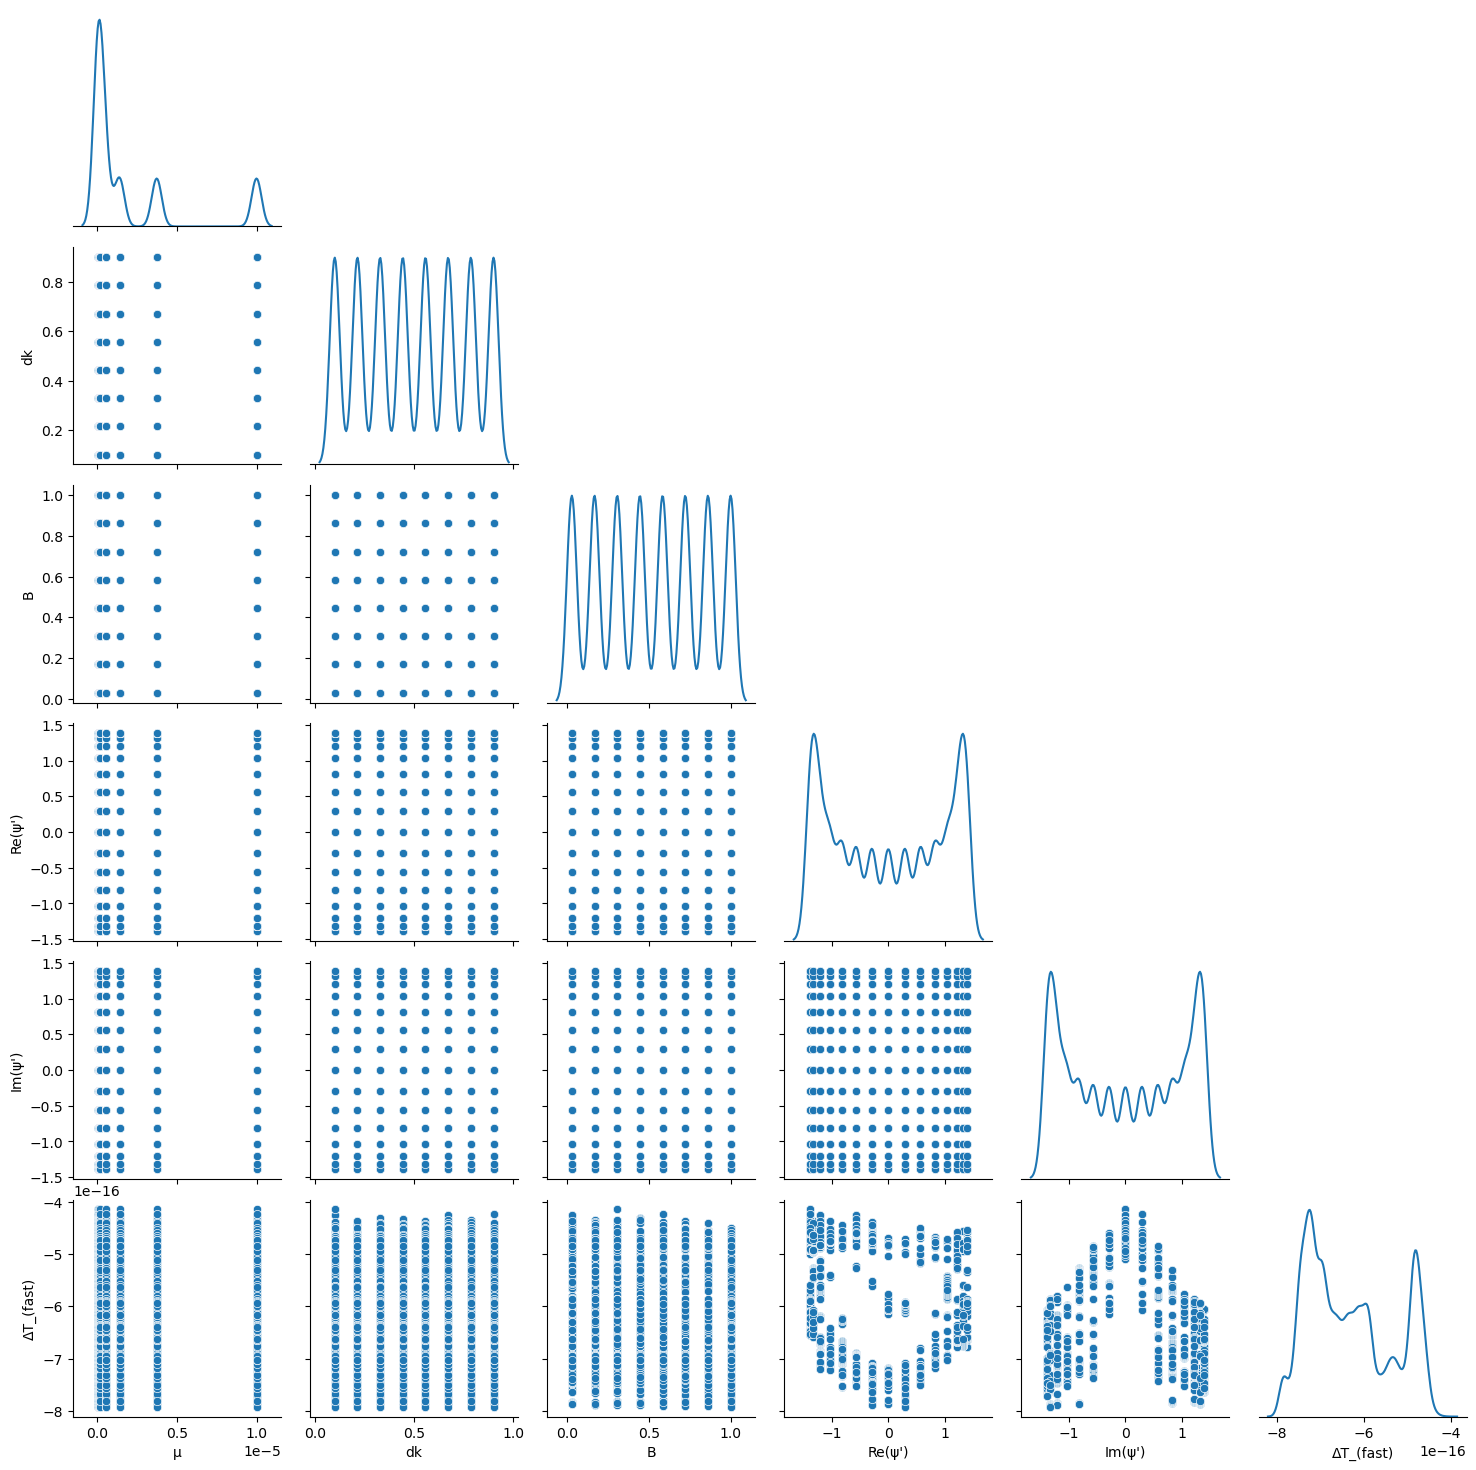

In [85]:
g = sns.PairGrid(dfa, diag_sharey=False, corner=True)

g.map_diag(sns.kdeplot)
g.map_lower(sns.scatterplot)

The constant and chaotic error terms are clearly visible. The constant term is very close to our results for the nonlinear case, while the chaotic term has some other structure to it. Lets subtract the $\mu$ independent term of the nonlinear case from the results, and see what we get.

In [86]:
t_pred = np.zeros((n_m, n_dk, n_b, n_g, n_g))

for mm in range(n_m): 
    for kk in range(n_dk):
        for nn in range (n_b):
            for ii in range(n_g):
                for jj in range(n_g):
                    # constant terms -- t_0 and intercept (error)
                    t_pred[mm,kk,nn,ii,jj] = pi /(eelib.kFAu+dk_g[kk]/1e-6/2.0) + consts['intercept']
                    # terms independent of mu (error)
                    t_pred[mm,kk,nn,ii,jj] += (np.real(dgridk[kk,ii,jj])**2 * consts['DR2'] 
                                             + np.imag(dgridk[kk,ii,jj])**2 * consts['DI2'] 
                                             + np.imag(dgridk[kk,ii,jj])**4 * consts['DI4'])

In [87]:
size = np.shape(fot.flatten())[0]
print(size)
npaf = np.zeros((size, 6))

sz = [n_dk*n_b*n_g**2, n_b*n_g**2, n_g **2, n_g, 1]

for imu in range(n_m):
    for ik in range(n_dk):
        for ib in range(n_b):
            for idr in range(n_g):
                for idi in range(n_g):
                    ind = imu*sz[0]+ik*sz[1]+ib*sz[2]+idr*sz[3]+idi
                    #npaf[ind, 0] = mfp[im]
                    #npaf[ind, 1] = ew[ik]
                    npaf[ind, 0] = mu_g[imu]
                    npaf[ind, 1] = dk_g[ik]
                    npaf[ind, 2] = B_g[ib]
                    npaf[ind, 3] = np.real(dgrid[idr, idi]) / (eelib.kFAu + dk_g[ik]/R /2.0)
                    npaf[ind, 4] = np.imag(dgrid[idr, idi]) / (eelib.kFAu + dk_g[ik]/R /2.0)
                    npaf[ind, 5] = fot0[imu, ik, ib, idr, idi]-t_pred[imu, ik, ib, idr, idi]

115200


In [88]:
dfa = pd.DataFrame(npaf, columns = ["\u03BC", "dk", "B", "Re(ψ')", "Im(ψ')", "\u0394T_(fast)"])

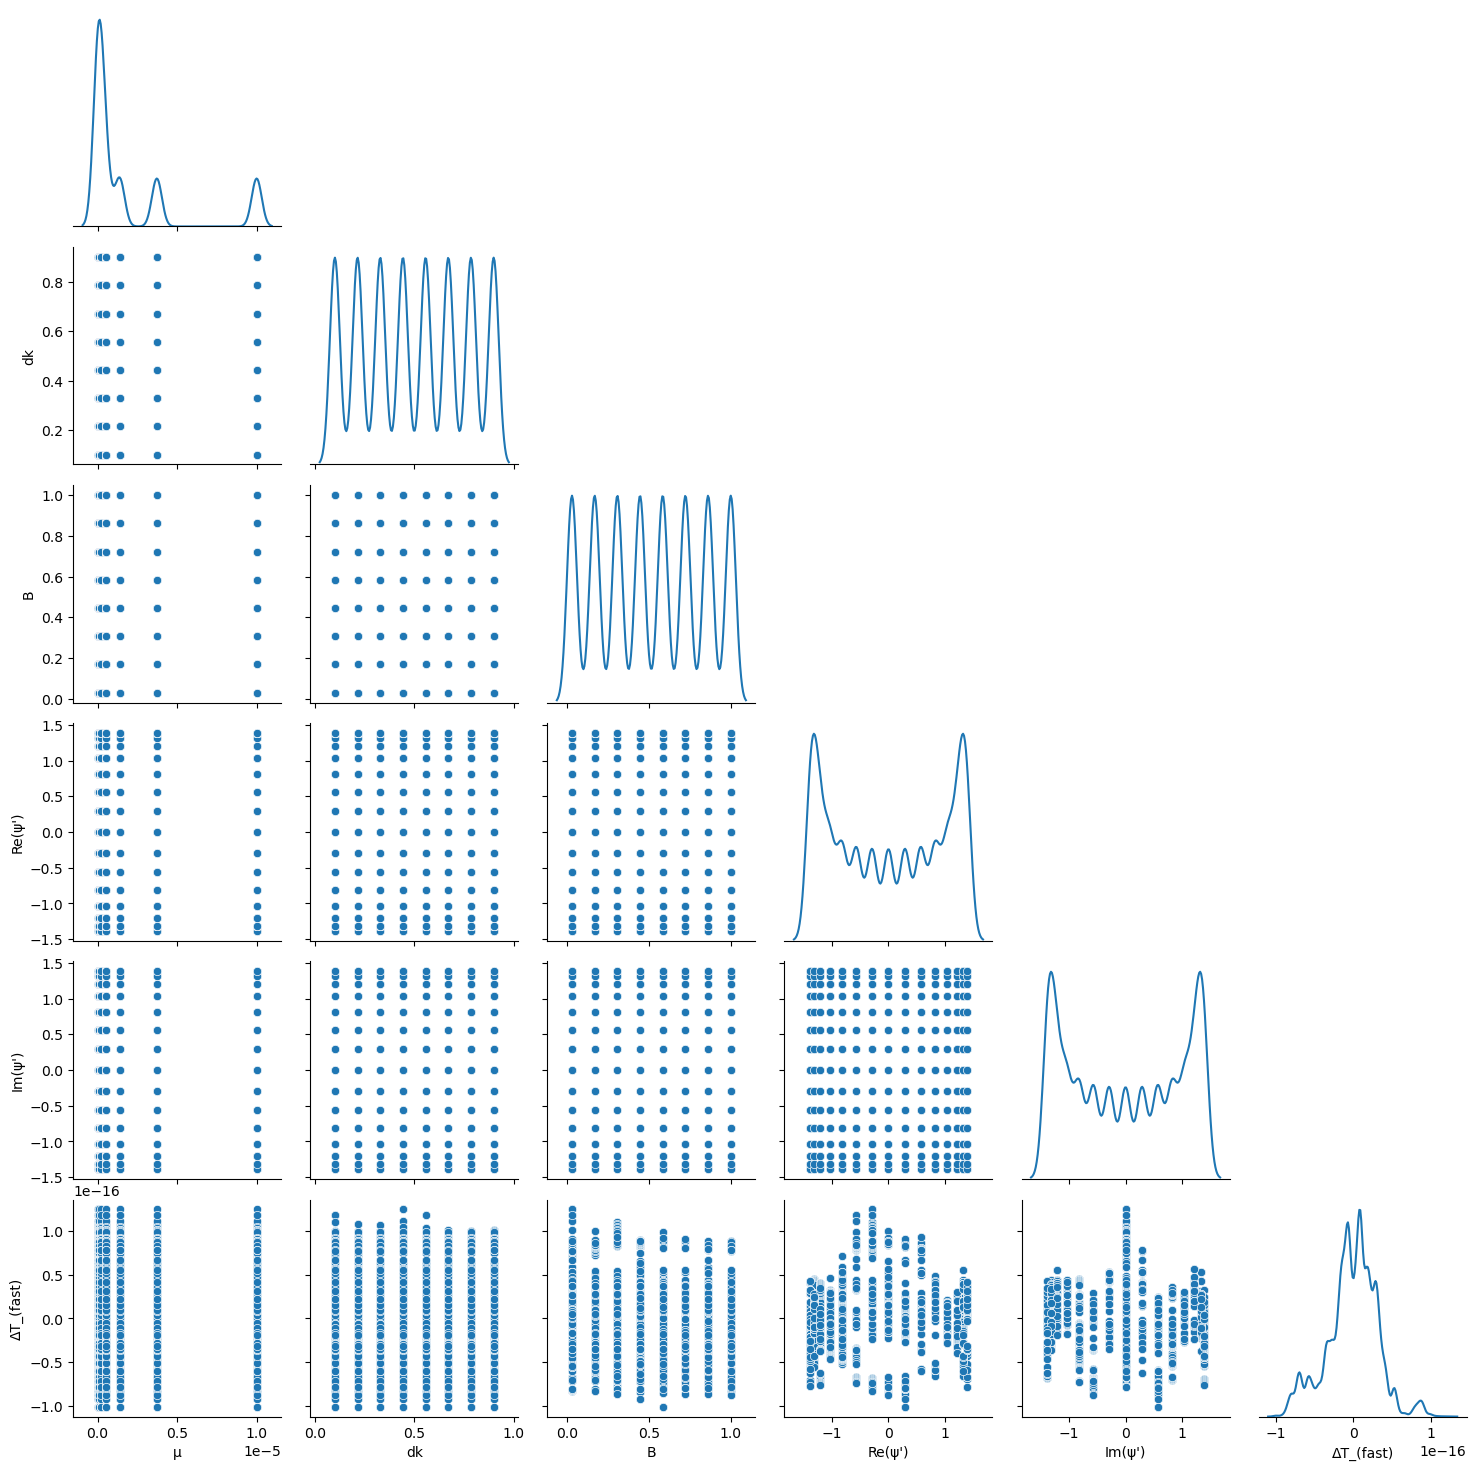

In [89]:
g = sns.PairGrid(dfa, diag_sharey=False, corner=True)

g.map_diag(sns.kdeplot)
g.map_lower(sns.scatterplot)

The error doesn't quite have the same dependence, but looks the same. I see a difference for $\mathrm{Im}(\psi^\prime) = 0$. The difference appears irrelevant, and there is no constant error term left.

# $\mu B \, \mathrm{Im}(\psi^\prime_0)$ Term, Attempt 3

I want to try to recreate my successful attempt at finding this term for my model.

In [93]:
consts

{'mA2': 3.675494115574291e-08,
 'mDIM': -9.499875618824098e-10,
 'mDI2': 3.674200444430406e-08,
 'mDR2': 3.674365054354659e-08,
 'm2': 8.522223583430349e-06,
 'm2DI2': 2.0556114758548036e-05,
 'm2DR2': 2.9358597545134476e-05,
 'm2DR4': 1.598207117609667e-05,
 'm2DI4': 1.5910577914323505e-05,
 'm2DI2R2': 3.182358695140475e-05,
 'intercept': -5.697364648383741e-16,
 'DI2': -2.7618261397447087e-16,
 'DR2': 8.0960114314636e-17,
 'DI4': 9.19298181818588e-17}

In [98]:
dfa

,μ,dk,B,Re(ψ'),Im(ψ'),ΔT_(fast)
0,1.000000e-08,0.1,0.03,-1.38081,-1.380810,6.118232e-19
1,1.000000e-08,0.1,0.03,-1.38081,-1.321546,-2.356642e-17
2,1.000000e-08,0.1,0.03,-1.38081,-1.204153,-1.337104e-17
3,1.000000e-08,0.1,0.03,-1.38081,-1.033794,1.743122e-18
4,1.000000e-08,0.1,0.03,-1.38081,-0.817964,-7.331562e-18
...,...,...,...,...,...,...
115195,1.000000e-05,0.9,1.00,1.38081,0.817964,7.221798e-15
115196,1.000000e-05,0.9,1.00,1.38081,1.033794,9.100093e-15
115197,1.000000e-05,0.9,1.00,1.38081,1.204153,1.063342e-14
115198,1.000000e-05,0.9,1.00,1.38081,1.321546,1.166401e-14


In [99]:
X = np.array([npaf[:,0]*npaf[:,2]*npaf[:,4]]).T

y = npaf[:,5]

reg = LinearRegression(fit_intercept=False).fit(X, y)

slope_mbi=reg.coef_
intercept_mbi=reg.intercept_

r = reg.score(X, y)

print(slope_mbi[0], intercept_mbi, r)

8.881913496260511e-10 0.0 0.9996664454493913


This is my old result. Our corrected term is as follows:

In [ ]:
8.881913496260701e-10 + -9.499875618824391e-10

-6.179621225636901e-11

In [100]:
consts['mDIM'] = -6.179621225636901e-11

Ok. Now to retest our model with the updated parameter.

In [101]:
# Here is our full model.

t_pred = np.zeros((n_m, n_dk, n_b, n_g, n_g))

for mm in range(n_m): 
    for kk in range(n_dk):
        for nn in range (n_b):
            for ii in range(n_g):
                for jj in range(n_g):
                    # constant terms -- t_0 and intercept (error)
                    t_pred[mm,kk,nn,ii,jj] = pi /(eelib.kFAu+dk_g[kk]/1e-6/2.0) + consts['intercept']
                    # terms independent of mu (error)
                    t_pred[mm,kk,nn,ii,jj] += (np.real(dgridk[kk,ii,jj])**2 * consts['DR2'] 
                                             + np.imag(dgridk[kk,ii,jj])**2 * consts['DI2'] 
                                             + np.imag(dgridk[kk,ii,jj])**4 * consts['DI4'])

                    # mu linear terms
                    t_pred[mm,kk,nn,ii,jj] += mu_g[mm]*(consts['mDR2'] * np.real(dgridk[kk,ii,jj])**2
                                                      + consts['mDI2'] * np.imag(dgridk[kk,ii,jj])**2
                                                      + consts['mA2']
                                                      + consts['mDIM'] * np.imag(dgridk[kk,ii,jj]) * B_g[nn])

                    # mu quadradic terms
                    t_pred[mm,kk,nn,ii,jj] += mu_g[mm]**2*(consts['m2']
                            + consts['m2DI2'] * np.imag(dgridk[kk,ii,jj])**2
                            + consts['m2DR2'] * np.real(dgridk[kk,ii,jj])**2 
                            + consts['m2DR4'] * np.real(dgridk[kk,ii,jj])**4 
                            + consts['m2DI4'] * np.imag(dgridk[kk,ii,jj])**4
                            + consts['m2DI2R2'] * np.real(dgridk[kk,ii,jj])**2 * np.imag(dgridk[kk,ii,jj])**2)

Maximum Error

In [102]:
np.max(fot-t_pred), np.min(fot-t_pred)

(1.3048743241978739e-16, -1.6540096097562107e-16)

Pandas and triangle plots

In [103]:
size = np.shape(fot.flatten())[0]
print(size)
npaf = np.zeros((size, 6))

sz = [n_dk*n_b*n_g**2, n_b*n_g**2, n_g **2, n_g, 1]

for imu in range(n_m):
    for ik in range(n_dk):
        for ib in range(n_b):
            for idr in range(n_g):
                for idi in range(n_g):
                    ind = imu*sz[0]+ik*sz[1]+ib*sz[2]+idr*sz[3]+idi
                    #npaf[ind, 0] = mfp[im]
                    #npaf[ind, 1] = ew[ik]
                    npaf[ind, 0] = mu_g[imu]
                    npaf[ind, 1] = dk_g[ik]
                    npaf[ind, 2] = B_g[ib]
                    npaf[ind, 3] = np.real(dgrid[idr, idi]) / (eelib.kFAu + dk_g[ik]/R /2.0)
                    npaf[ind, 4] = np.imag(dgrid[idr, idi]) / (eelib.kFAu + dk_g[ik]/R /2.0)
                    npaf[ind, 5] = fot[imu, ik, ib, idr, idi]-t_pred[imu, ik, ib, idr, idi]

115200


In [104]:
dfa = pd.DataFrame(npaf, columns = ["\u03BC", "dk", "B", "Re(ψ')", "Im(ψ')", "\u0394T_(fast)"])

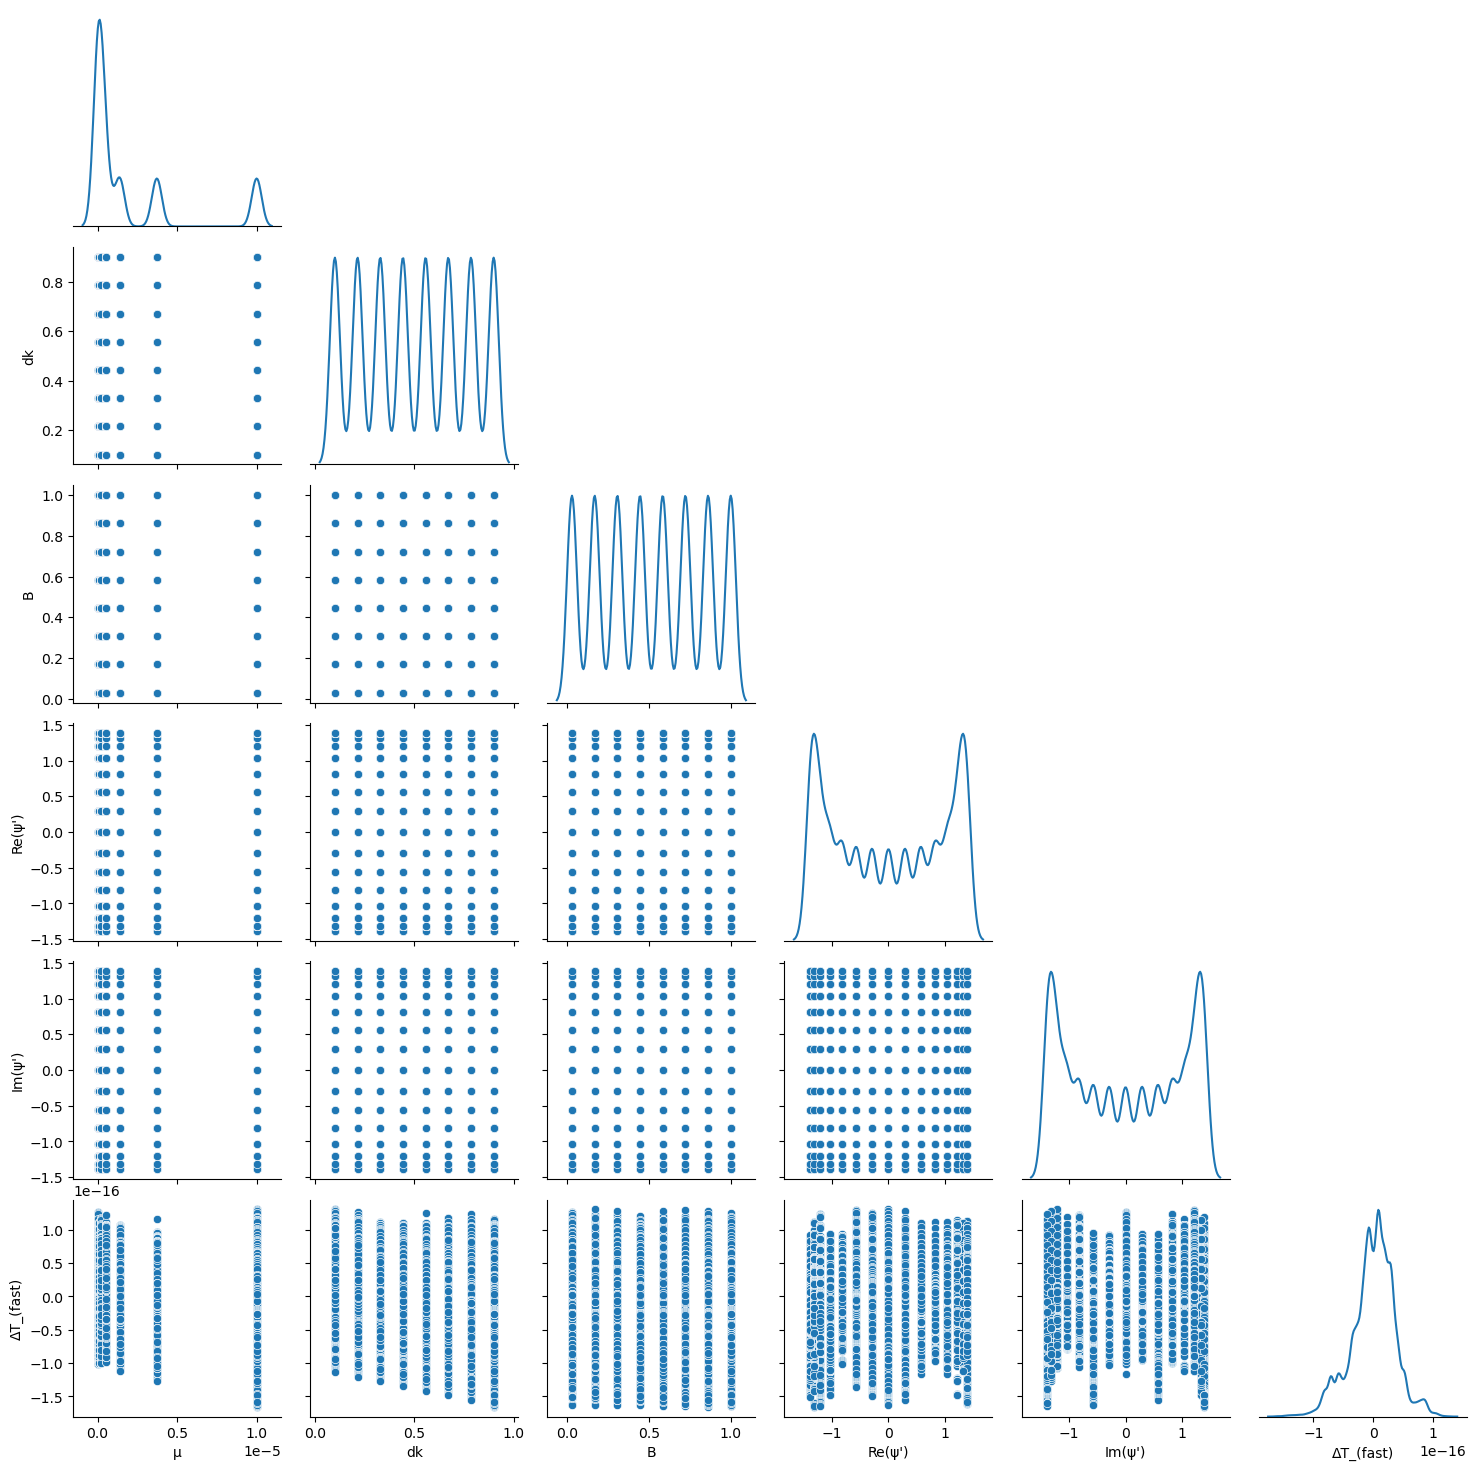

In [105]:
g = sns.PairGrid(dfa, diag_sharey=False, corner=True)

g.map_diag(sns.kdeplot)
g.map_lower(sns.scatterplot)

The model works well.

# Final Notes

$k_0$ has been run and determined to be too complex for a first analysis. This work will be put aside for now. My results are valid only for gold. However the general shape of the results should not change with $k_0$, only the exact value of parameters.

Varying $R$ and $A_0$ appear to cause a growth in error. I already knew that, but recieved conformation. However, I know that keeping them fixed and rescaling other variables in the code is a possibility. $R$ rescales $B$ and $t_{fin}$, while $A_0$ rescales $\mu$ and alters $\psi^\prime$ in an unknown fashion. Since $\psi^\prime$ is fit for, and just an intermediate, it is easier to just ignore this, as rescaling $\psi^\prime$ is unnecessary. We work with $\psi^\prime$ defined for $A_0 = 1$, and we know the final results will be identical to the rescaled version, despite not knowing $\psi^\prime$ within the rescaled version. 

$R$ issues have been removed by changing how dk scales with $R$, and our model works for all applicable values of $R$.

We have a beautiful model of a weakly non-linear system, despite solving for a time-independent case. Solinoids will not emerge, of course, since we removed that possibility at the beginning, but that doesn't prevent certain interesting aspects of non-linear dynamics from occuring.

With respect to error -- my assumption is that non-linear error is of much lower order, and doesn't appear. While I have good reason to believe this is the case if it is not true, it invalidates my results. Testing this particular hypothesis will be quite difficult.

As far as I can tell, the drop in power is related to a systematic underestimation of the period, which exists even for the linear case. The power drop appears near-indentical within both cases, and there exists a correction to the period independent of $\mu$ with partial chaotic dependence on other parameters. When the terms line up properly, the error is as the error seen in the above modeling, but when they don't, the error is much larger. Interpolation is relatively safe, so we can just avoid the values which don't line up properly. 